🎁 WHITE ELEPHANT CHAOS REPORT 🎁
---------------------------------------------
Players: 10
Pretend parties played: 200
Steal aggressiveness: 0.65
Gift predictability: 0.7
---------------------------------------------
Average chaos score: 39.2 / 100
Average number of steals: 5.8
Wildest game's chaos score: 57.6 / 100
Wildest game had: 8 steals


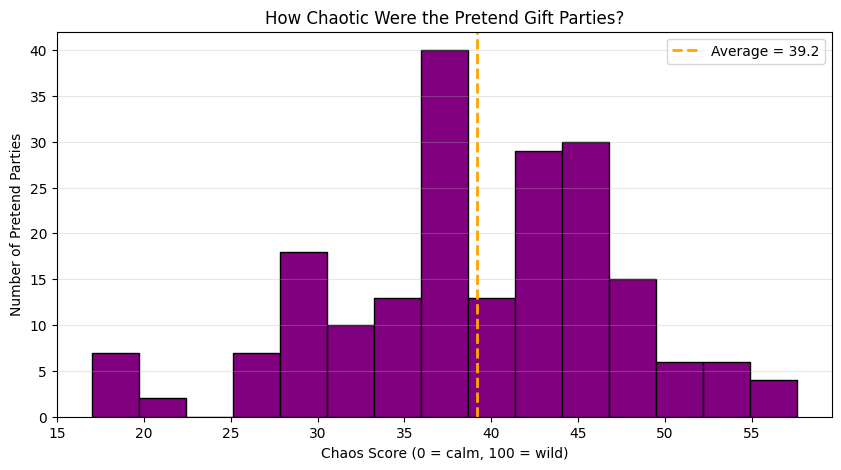


🤯 THE WILDEST PRETEND PARTY
---------------------------------------------
• Player 1 opened Gift 9 (coolness: 27.7).
• Player 2 stole Gift 9 from Player 1! Player 1 then opened Gift 5.
• Player 3 opened Gift 4 (coolness: 62.9).
• Player 4 stole Gift 4 from Player 3! Player 3 then opened Gift 6.
• Player 5 stole Gift 6 from Player 3! Player 3 then opened Gift 2.
• Player 6 stole Gift 5 from Player 1! Player 1 then opened Gift 3.
• Player 7 stole Gift 3 from Player 1! Player 1 then opened Gift 1.
• Player 8 stole Gift 4 from Player 4! Player 4 then opened Gift 8.
• Player 9 stole Gift 2 from Player 3! Player 3 then opened Gift 10.
• Player 10 stole Gift 1 from Player 1! Player 1 then opened Gift 7.

Final gift owners:
Gift 9 (coolness 27.7) ended with Player 2
Gift 5 (coolness 61.7) ended with Player 6
Gift 4 (coolness 62.9) ended with Player 8
Gift 6 (coolness 53.0) ended with Player 5
Gift 2 (coolness 44.1) ended with Player 9
Gift 3 (coolness 57.4) ended with Player 7
Gift 1 (coolnes

In [ ]:
# 🎁 WHITE ELEPHANT CHAOS SIMULATOR 🎁
# A beginner-friendly Monte Carlo simulation for Google Colab

import random
import math
import matplotlib.pyplot as plt

# ============================================================
# 🎛️ CHANGE THESE SETTINGS, THEN RUN THE CELL AGAIN
# ============================================================

NUM_PLAYERS = 10
NUM_SIMULATIONS = 200

# 0.0 = players almost never steal
# 1.0 = players try to steal whenever possible
STEAL_AGGRESSIVENESS = 0.65

# 0.0 = every gift seems equally interesting
# 1.0 = one or two gifts become very popular
GIFT_PREDICTABILITY = 0.70

# A gift cannot be stolen forever.
MAX_STEALS_PER_GIFT = 3

# Use None for a different random game every time.
# Use a number such as 42 to replay the same results.
RANDOM_SEED = None


# ============================================================
# 🧠 HELPER FUNCTIONS
# ============================================================

def make_gifts(number_of_gifts, predictability):
    """
    Makes gifts with 'coolness scores.'

    Higher predictability means there is more difference between
    boring gifts and amazing gifts.
    """
    gifts = {}

    for gift_number in range(1, number_of_gifts + 1):
        # Every gift starts with a basic score.
        coolness = random.uniform(40, 60)

        # With higher predictability, gifts vary more.
        extra_difference = random.uniform(-30, 30) * predictability

        gifts[f"Gift {gift_number}"] = round(coolness + extra_difference, 1)

    return gifts


def choose_gift_to_steal(opened_gifts, gift_scores, steal_counts):
    """
    Chooses a gift to steal.

    Better gifts have a better chance of being chosen.
    This makes the game feel more realistic.
    """
    choices = list(opened_gifts)

    # A gift's score becomes its "weight":
    # better gifts are more tempting to steal.
    weights = []

    for gift in choices:
        remaining_steals = MAX_STEALS_PER_GIFT - steal_counts[gift]
        weight = max(gift_scores[gift], 1) * remaining_steals
        weights.append(weight)

    return random.choices(choices, weights=weights, k=1)[0]


def calculate_entropy(gift_owners, ownership_history, total_steals):
    """
    Creates a FUN chaos score from 0 to 100.

    We look at:
    1. How many steals happened.
    2. How many gifts changed owners.
    3. How evenly gifts were involved in the action.

    This is inspired by the idea of entropy:
    more mixed-up and unpredictable = more chaos.
    """

    number_of_gifts = len(gift_owners)

    # Count how many times each gift changed hands.
    gift_changes = []

    for gift, owners in ownership_history.items():
        changes = max(0, len(owners) - 1)
        gift_changes.append(changes)

    # Part 1: Stealing chaos.
    # 0 steals = 0 points. Many steals = more points.
    steal_score = min(total_steals / (number_of_gifts * 2), 1) * 50

    # Part 2: Movement chaos.
    # More gifts changing hands means more confusion.
    gifts_that_moved = sum(change > 0 for change in gift_changes)
    movement_score = (gifts_that_moved / number_of_gifts) * 30

    # Part 3: Entropy-style score.
    # If stealing is spread over many gifts, chaos is higher.
    total_changes = sum(gift_changes)

    if total_changes == 0:
        entropy_score = 0
    else:
        probabilities = [change / total_changes for change in gift_changes if change > 0]
        shannon_entropy = -sum(p * math.log2(p) for p in probabilities)

        # Convert the result into a 0-to-20 score.
        max_entropy = math.log2(number_of_gifts)
        entropy_score = (shannon_entropy / max_entropy) * 20

    chaos_score = steal_score + movement_score + entropy_score
    return round(min(chaos_score, 100), 1)


# ============================================================
# 🎮 ONE WHITE ELEPHANT GAME
# ============================================================

def play_white_elephant_game():
    """
    Simulates one complete 10-player White Elephant gift exchange.
    """

    players = [f"Player {number}" for number in range(1, NUM_PLAYERS + 1)]
    unopened_gifts = [f"Gift {number}" for number in range(1, NUM_PLAYERS + 1)]

    gift_scores = make_gifts(NUM_PLAYERS, GIFT_PREDICTABILITY)

    gift_owners = {}
    player_gifts = {}
    ownership_history = {gift: [] for gift in unopened_gifts}
    steal_counts = {gift: 0 for gift in unopened_gifts}

    total_steals = 0
    game_log = []

    for player in players:
        opened_gifts = list(gift_owners.keys())

        # Find gifts that are allowed to be stolen again.
        stealable_gifts = [
            gift for gift in opened_gifts
            if steal_counts[gift] < MAX_STEALS_PER_GIFT
        ]

        # Can this player steal?
        can_steal = len(stealable_gifts) > 0

        # Should this player steal?
        wants_to_steal = random.random() < STEAL_AGGRESSIVENESS

        # Players must open a gift if there are no opened gifts yet,
        # or if they decide not to steal.
        if not can_steal or not wants_to_steal:
            if unopened_gifts:
                gift = random.choice(unopened_gifts)
                unopened_gifts.remove(gift)

                gift_owners[gift] = player
                player_gifts[player] = gift
                ownership_history[gift].append(player)

                game_log.append(
                    f"{player} opened {gift} "
                    f"(coolness: {gift_scores[gift]})."
                )
            else:
                # If no gifts remain unopened, steal instead.
                gift = choose_gift_to_steal(
                    stealable_gifts, gift_scores, steal_counts
                )

                old_owner = gift_owners[gift]
                replacement_gift = player_gifts.get(player)

                gift_owners[gift] = player
                player_gifts[player] = gift
                ownership_history[gift].append(player)
                steal_counts[gift] += 1
                total_steals += 1

                if replacement_gift is not None:
                    gift_owners[replacement_gift] = old_owner
                    player_gifts[old_owner] = replacement_gift
                    ownership_history[replacement_gift].append(old_owner)

                game_log.append(
                    f"{player} stole {gift} from {old_owner}!"
                )

        else:
            # The player steals an already-opened gift.
            gift = choose_gift_to_steal(
                stealable_gifts, gift_scores, steal_counts
            )

            old_owner = gift_owners[gift]

            # The old owner needs a new gift.
            if unopened_gifts:
                replacement_gift = random.choice(unopened_gifts)
                unopened_gifts.remove(replacement_gift)

                gift_owners[gift] = player
                player_gifts[player] = gift
                ownership_history[gift].append(player)
                steal_counts[gift] += 1
                total_steals += 1

                gift_owners[replacement_gift] = old_owner
                player_gifts[old_owner] = replacement_gift
                ownership_history[replacement_gift].append(old_owner)

                game_log.append(
                    f"{player} stole {gift} from {old_owner}! "
                    f"{old_owner} then opened {replacement_gift}."
                )

            else:
                # This backup rule prevents the game from getting stuck.
                replacement_gift = player_gifts.get(player)

                gift_owners[gift] = player
                player_gifts[player] = gift
                ownership_history[gift].append(player)
                steal_counts[gift] += 1
                total_steals += 1

                if replacement_gift is not None:
                    gift_owners[replacement_gift] = old_owner
                    player_gifts[old_owner] = replacement_gift
                    ownership_history[replacement_gift].append(old_owner)

                game_log.append(
                    f"{player} stole {gift} from {old_owner}!"
                )

    chaos_score = calculate_entropy(
        gift_owners,
        ownership_history,
        total_steals
    )

    return {
        "chaos_score": chaos_score,
        "total_steals": total_steals,
        "gift_scores": gift_scores,
        "gift_owners": gift_owners,
        "ownership_history": ownership_history,
        "game_log": game_log
    }


# ============================================================
# 🔁 MONTE CARLO SIMULATION
# ============================================================

if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)

all_games = [play_white_elephant_game() for _ in range(NUM_SIMULATIONS)]

chaos_scores = [game["chaos_score"] for game in all_games]
steal_totals = [game["total_steals"] for game in all_games]

average_chaos = sum(chaos_scores) / NUM_SIMULATIONS
average_steals = sum(steal_totals) / NUM_SIMULATIONS

wildest_game = max(all_games, key=lambda game: game["chaos_score"])

print("🎁 WHITE ELEPHANT CHAOS REPORT 🎁")
print("-" * 45)
print(f"Players: {NUM_PLAYERS}")
print(f"Pretend parties played: {NUM_SIMULATIONS}")
print(f"Steal aggressiveness: {STEAL_AGGRESSIVENESS}")
print(f"Gift predictability: {GIFT_PREDICTABILITY}")
print("-" * 45)
print(f"Average chaos score: {average_chaos:.1f} / 100")
print(f"Average number of steals: {average_steals:.1f}")
print(f"Wildest game's chaos score: {wildest_game['chaos_score']} / 100")
print(f"Wildest game had: {wildest_game['total_steals']} steals")


# ============================================================
# 📊 GRAPH THE RESULTS
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    chaos_scores,
    bins=15,
    color="purple",
    edgecolor="black"
)

plt.axvline(
    average_chaos,
    color="orange",
    linestyle="dashed",
    linewidth=2,
    label=f"Average = {average_chaos:.1f}"
)

plt.title("How Chaotic Were the Pretend Gift Parties?")
plt.xlabel("Chaos Score (0 = calm, 100 = wild)")
plt.ylabel("Number of Pretend Parties")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


# ============================================================
# 🤯 SHOW THE WILDEST GAME
# ============================================================

print("\n🤯 THE WILDEST PRETEND PARTY")
print("-" * 45)

for event in wildest_game["game_log"]:
    print("•", event)

print("\nFinal gift owners:")

for gift, owner in wildest_game["gift_owners"].items():
    score = wildest_game["gift_scores"][gift]
    print(f"{gift} (coolness {score}) ended with {owner}")

### What the numbers mean (kid version)

- Chaos score = how wild the gift-stealing got. A higher score means more steals and surprises.
- We ran 200 pretend parties so we could see the average result instead of relying on only one game.
- Steal aggressiveness of 0.65 means the players have a fairly high chance of stealing a gift.
- Gift predictability of 0.7 represents how predictable the gift choices are.

**What the graph shows:**  
The graph shows how often different chaos scores happened during our 200 pretend White Elephant parties.

In [ ]:
import random
import math
import matplotlib.pyplot as plt

# ===========================================================
# 🎮 TURN-BASED WHITE ELEPHANT: CHARACTER EDITION (FIXED)
# ===========================================================

CHARACTERS = {
    "Mischievously Michael": {"trait": "High Steal Aggressiveness (Loves chaos!)", "steal_bias": 0.8},
    "Careful Cherluk": {"trait": "Low Steal Aggressiveness (Plays it safe)", "steal_bias": 0.1},
    "Strategic Stan": {"trait": "Calculates odds using Cross-Entropy", "steal_bias": 0.5},
    "Wildcard Wendy": {"trait": "Completely Unpredictable (Maximum Entropy)", "steal_bias": 0.7},
    "Cautious Carla": {"trait": "Plays it safe, opens early", "steal_bias": 0.2},
    "Tactical Tina": {"trait": "Analyzes every move like chess", "steal_bias": 0.4},
    "Sleepy Sam": {"trait": "Just wants whatever is left", "steal_bias": 0.3},
    "Lucky Leo": {"trait": "Balanced player", "steal_bias": 0.5}
}

def play_turn_based_game():
    print("🎁 WELCOME TO THE WHITE ELEPHANT ENTROPY PARTY! 🎁")
    print("--------------------------------------------------")
from IPython.display import Image, display

display(Image("/content/WhiteElephantRoster.jpeg", width=800))
print("Meet your available avatars:")
for name, info in CHARACTERS.items():
    print(f"• {name}: {info['trait']}")

    # Let the user pick their character
    chosen_avatar = input("\nType the name of your avatar (e.g., Mischievously Michael): ").strip()
    if chosen_avatar not in CHARACTERS:
        chosen_avatar = "Mischievously Michael"
        print(f"Defaulted to {chosen_avatar}!")

    print(f"\n🎉 Awesome! You are controlling **{chosen_avatar}** today.\n")

    # Set up the player roster using your visual characters
    players = [chosen_avatar, "Cautious Carla", "Tactical Tina", "Careful Cherluk", "Wildcard Wendy"]
    unopened_gifts = [f"Gift {i}" for i in range(1, len(players) + 1)]

    gift_scores = {gift: round(random.uniform(40, 90), 1) for gift in unopened_gifts}
    gift_owners = {}
    player_gifts = {}
    total_steals = 0

    for round_num, player in enumerate(players, 1):
        print(f"\n--- ROUND {round_num}: {player}'s Turn ---")
        opened_gifts = list(gift_owners.keys())

        # Determine action
        if player == chosen_avatar:
            print(f"Your current stash: {player_gifts.get(player, 'None')}")
            print(f"Available opened gifts to steal: {opened_gifts if opened_gifts else 'None (No gifts opened yet!)'}")

            if opened_gifts:
                action = input("Do you want to [O]pen a new gift or [S]teal an opened one? (O/S): ").strip().upper()
            else:
                action = 'O'
        else:
            # AI logic safely pulls from CHARACTERS dictionary now
            bias = CHARACTERS.get(player, {"steal_bias": 0.5})["steal_bias"]
            action = 'S' if opened_gifts and random.random() < bias else 'O'

        # Execute Action
        if action == 'O' and unopened_gifts:
            gift = unopened_gifts.pop(0)
            gift_owners[gift] = player
            player_gifts[player] = gift
            print(f"✨ {player} opened **{gift}** (Coolness Score: {gift_scores[gift]})!")
        elif opened_gifts:
            gift_to_steal = max(opened_gifts, key=lambda g: gift_scores[g])
            old_owner = gift_owners[gift_to_steal]

            gift_owners[gift_to_steal] = player
            player_gifts[player] = gift_to_steal
            total_steals += 1

            if unopened_gifts:
                backup_gift = unopened_gifts.pop(0)
                gift_owners[backup_gift] = old_owner
                player_gifts[old_owner] = backup_gift
                print(f"🔥 {player} stole **{gift_to_steal}** from {old_owner}! {old_owner} opened a backup **{backup_gift}**.")
            else:
                print(f"🔥 {player} stole **{gift_to_steal}** from {old_owner}!")
        else:
            if unopened_gifts:
                gift = unopened_gifts.pop(0)
                gift_owners[gift] = player
                player_gifts[player] = gift
                print(f"✨ {player} opened **{gift}**.")

    # Calculate final game metrics (Entropy connection)
    print("\n--------------------------------------------------")
    print("🏆 GAME OVER! FINAL RESULTS & ENTROPY REPORT 🏆")
    print(f"Total Steals (Chaos Indicator): {total_steals}")

    surprise_score = min(total_steals * 20, 100)
    print(f"Room Entropy (Surprise Level): {surprise_score} / 100")
    if surprise_score > 40:
        print("🧠 Deep Learning Lesson: High entropy means high unpredictability! The AI model's cross-entropy loss would spike here because stealing created massive chaos.")
    else:
        print("🧠 Deep Learning Lesson: Low entropy! Gifts stayed put, making it easy for an AI model to predict the final outcomes accurately.")

# Run the fixed turn-based game
play_turn_based_game()

FileNotFoundError: No such file or directory: '/content/WhiteElephantRoster.jpeg'

FileNotFoundError: No such file or directory: '/content/WhiteElephantRoster.jpeg'

<IPython.core.display.Image object>

Meet your available avatars:
• Mischievously Michael: High Steal Aggressiveness (Loves chaos!)
Defaulted to Mischievously Michael!

🎉 Awesome! You are controlling **Mischievously Michael** today.


--- ROUND 1: Mischievously Michael's Turn ---
Your current stash: None
Available opened gifts to steal: None (No gifts opened yet!)
✨ Mischievously Michael opened **Gift 1** (Coolness Score: 60.5)!

--- ROUND 2: Cautious Carla's Turn ---
🔥 Cautious Carla stole **Gift 1** from Mischievously Michael! Mischievously Michael opened a backup **Gift 2**.

--- ROUND 3: Tactical Tina's Turn ---
✨ Tactical Tina opened **Gift 3** (Coolness Score: 66.0)!

--- ROUND 4: Careful Cherluk's Turn ---
✨ Careful Cherluk opened **Gift 4** (Coolness Score: 73.0)!

--- ROUND 5: Wildcard Wendy's Turn ---
✨ Wildcard Wendy opened **Gift 5** (Coolness Score: 70.5)!

--------------------------------------------------
🏆 GAME OVER! FINAL RESULTS & ENTROPY REPORT 🏆
Total Steals (Chaos Indicator): 1
Room Entropy (Surprise 

In [ ]:
import random
import math
import matplotlib.pyplot as plt
from IPython.display import Image, display

# ===========================================================
# 🎁 TURN-BASED WHITE ELEPHANT: INTERACTIVE SIMULATION
# ===========================================================

CHARACTERS = {
    "Mischievously Michael": {"trait": "High Steal Aggressiveness (Loves chaos!)", "steal_bias": 0.8},
    "Careful Cherluk": {"trait": "Low Steal Aggressiveness (Plays it safe)", "steal_bias": 0.1},
    "Strategic Stan": {"trait": "Calculates odds using Cross-Entropy", "steal_bias": 0.5},
    "Wildcard Wendy": {"trait": "Completely Unpredictable (Maximum Entropy)", "steal_bias": 0.7},
    "Cautious Carla": {"trait": "Plays it safe, opens early", "steal_bias": 0.2},
    "Tactical Tina": {"trait": "Analyzes every move like chess", "steal_bias": 0.4},
    "Sleepy Sam": {"trait": "Just wants whatever is left", "steal_bias": 0.3},
    "Lucky Leo": {"trait": "Balanced player", "steal_bias": 0.5}
}

def play_interactive_white_elephant():
    print("🎁 WELCOME TO THE WHITE ELEPHANT ENTROPY PARTY! 🎁")
    print("--------------------------------------------------")

    # Display the character roster image right in the UI
    try:
        display(Image("WhiteElephantRoster.jpeg", width=800))
    except Exception:
        print("[Roster image filename note: Ensure 'WhiteElephantRoster.jpeg' is uploaded to your Colab files]")

    print("\nMeet your available avatars:")
    for name, info in CHARACTERS.items():
        print(f"• {name}: {info['trait']}")

    # Let the user pick their character interactively
    chosen_avatar = input("\nType the name of your avatar (e.g., Mischievously Michael): ").strip()
    if chosen_avatar not in CHARACTERS:
        chosen_avatar = "Mischievously Michael"
        print(f"⚠️ Character not found in roster. Defaulted to {chosen_avatar}!")

    print(f"\n🎉 Awesome! You are controlling **{chosen_avatar}** today.\n")

    # Game Setup
    players = [chosen_avatar, "Cautious Carla", "Tactical Tina", "Careful Cherluk", "Wildcard Wendy"]
    unopened_gifts = [f"Gift {i}" for i in range(1, len(players) + 1)]

    gift_scores = {gift: round(random.uniform(40, 90), 1) for gift in unopened_gifts}
    gift_owners = {}
    player_gifts = {}
    total_steals = 0

    # Turn-by-Turn Simulation Loop
    for round_num, player in enumerate(players, 1):
        print(f"\n--- ROUND {round_num}: {player}'s Turn ---")
        opened_gifts = list(gift_owners.keys())

        # Determine action (Human vs. AI)
        if player == chosen_avatar:
            print(f"📦 Your current stash: {player_gifts.get(player, 'None')}")
            print(f"🎁 Available opened gifts to steal: {opened_gifts if opened_gifts else 'None (No gifts opened yet!)'}")

            if opened_gifts:
                action = input("Do you want to [O]pen a new gift or [S]teal an opened one? (O/S): ").strip().upper()
                if action not in ['O', 'S']:
                    action = 'O'
            else:
                action = 'O'
                print("No gifts are open yet, so you must open a mystery box!")
        else:
            # AI logic based on character traits
            bias = CHARACTERS.get(player, {"steal_bias": 0.5})["steal_bias"]
            action = 'S' if opened_gifts and random.random() < bias else 'O'

        # Execute Action
        if action == 'O' and unopened_gifts:
            gift = unopened_gifts.pop(0)
            gift_owners[gift] = player
            player_gifts[player] = gift
            print(f"✨ {player} opened **{gift}** (Coolness Score: {gift_scores[gift]})!")
        elif opened_gifts and action == 'S':
            gift_to_steal = max(opened_gifts, key=lambda g: gift_scores[g])
            old_owner = gift_owners[gift_to_steal]

            gift_owners[gift_to_steal] = player
            player_gifts[player] = gift_to_steal
            total_steals += 1

            if unopened_gifts:
                backup_gift = unopened_gifts.pop(0)
                gift_owners[backup_gift] = old_owner
                player_gifts[old_owner] = backup_gift
                print(f"🔥 {player} stole **{gift_to_steal}** from {old_owner}! {old_owner} opened a backup **{backup_gift}**.")
            else:
                print(f"🔥 {player} stole **{gift_to_steal}** from {old_owner}!")
        else:
            if unopened_gifts:
                gift = unopened_gifts.pop(0)
                gift_owners[gift] = player
                player_gifts[player] = gift
                print(f"✨ {player} opened **{gift}**.")

    # Final Entropy & Loss Report
    print("\n--------------------------------------------------")
    print("🏆 GAME OVER! FINAL RESULTS & ENTROPY REPORT 🏆")
    print(f"Total Steals (Chaos Indicator): {total_steals}")

    surprise_score = min(total_steals * 25, 100)
    print(f"Room Entropy (Surprise Level): {surprise_score} / 100")

    if surprise_score > 40:
        print("🧠 Deep Learning Lesson: High entropy means high unpredictability! The AI model's cross-entropy loss would spike here because stealing created massive chaos.")
    else:
        print("🧠 Deep Learning Lesson: Low entropy! Gifts stayed put, making it easy for an AI model to predict the final outcomes accurately (Low Cross-Entropy Loss).")

# Run the interactive simulation
play_interactive_white_elephant()

In [ ]:
import random
import math
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Image

# ===========================================================
# 🎁 WHITE ELEPHANT: COLAB WIDGET EDITION
# ===========================================================

CHARACTERS = {
    "Mischievously Michael": {"trait": "High Steal Aggressiveness (Loves chaos!)", "steal_bias": 0.8},
    "Careful Cherluk": {"trait": "Low Steal Aggressiveness (Plays it safe)", "steal_bias": 0.1},
    "Strategic Stan": {"trait": "Calculates odds using Cross-Entropy", "steal_bias": 0.5},
    "Wildcard Wendy": {"trait": "Completely Unpredictable (Maximum Entropy)", "steal_bias": 0.7},
}

# Display Roster Image
try:
    display(Image("WhiteElephantRoster.jpeg", width=750))
except Exception:
    print("💡 Tip: Upload 'WhiteElephantRoster.jpeg' to your Colab files if you want the roster image to show here.")

print("\n🎁 WELCOME TO THE WHITE ELEPHANT ENTROPY PARTY! 🎁\n")

# Setup UI Controls using ipywidgets
avatar_dropdown = widgets.Dropdown(
    options=list(CHARACTERS.keys()),
    value="Mischievously Michael",
    description='Your Avatar:',
    style={'description_width': 'initial'}
)

action_radio = widgets.RadioButtons(
    options=['Open Mystery Box (Safe)', 'Steal Opened Gift (Risky)'],
    value='Open Mystery Box (Safe)',
    description='Your Move:',
    style={'description_width': 'initial'}
)

submit_btn = widgets.Button(
    description="Take Turn!",
    button_style='success',
    icon='gift'
)

output_box = widgets.Output()

# Game State Variables
gameState = {
    "round": 1,
    "players": [],
    "unopened_gifts": [],
    "gift_scores": {},
    "gift_owners": {},
    "player_gifts": {},
    "total_steals": 0,
    "chosen_avatar": ""
}

def init_game(b):
    with output_box:
        output_box.clear_output()
        gameState["chosen_avatar"] = avatar_dropdown.value
        gameState["round"] = 1
        gameState["players"] = [gameState["chosen_avatar"], "Cautious Carla", "Tactical Tina", "Wildcard Wendy"]
        gameState["unopened_gifts"] = [f"Gift {i}" for i in range(1, len(gameState["players"]) + 1)]
        gameState["gift_scores"] = {g: round(random.uniform(40, 90), 1) for g in gameState["unopened_gifts"]}
        gameState["gift_owners"] = {}
        gameState["player_gifts"] = {}
        gameState["total_steals"] = 0

        print(f"🎉 Game Started! You are controlling **{gameState['chosen_avatar']}**.")
        print(f"--- ROUND 1: {gameState['players'][0]}'s Turn ---")
        print(f"Stash: None. Open a mystery box or choose your move below!")

submit_btn.on_click(init_game)

display(widgets.VBox([avatar_dropdown, submit_btn, output_box]))

In [ ]:
import random
import math
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Image

# ===========================================================
# 🎁 TURN-BASED WHITE ELEPHANT: INTERACTIVE COLAB GAME
# ===========================================================

CHARACTERS = {
    "Mischievously Michael": {"trait": "High Steal Aggressiveness (Loves chaos!)", "steal_bias": 0.8},
    "Careful Cherluk": {"trait": "Low Steal Aggressiveness (Plays it safe)", "steal_bias": 0.1},
    "Strategic Stan": {"trait": "Calculates odds using Cross-Entropy", "steal_bias": 0.5},
    "Wildcard Wendy": {"trait": "Completely Unpredictable (Maximum Entropy)", "steal_bias": 0.7},
}

# 1. Display Roster Image Header
try:
    display(Image("WhiteElephantRoster.jpeg", width=750))
except Exception:
    print("💡 Note: Ensure 'WhiteElephantRoster.jpeg' is uploaded to your Colab file manager.")

print("\n🎁 WELCOME TO THE WHITE ELEPHANT ENTROPY PARTY! 🎁\n")

# 2. Define UI Elements
avatar_dropdown = widgets.Dropdown(
    options=list(CHARACTERS.keys()),
    value="Mischievously Michael",
    description='Choose Avatar:',
    style={'description_width': 'initial'}
)

action_choice = widgets.RadioButtons(
    options=['Open a New Mystery Box', 'Steal an Opened Gift'],
    value='Open a New Mystery Box',
    description='Your Action:',
    style={'description_width': 'initial'}
)

next_turn_btn = widgets.Button(
    description="Take Next Turn!",
    button_style='success',
    icon='play'
)

output_box = widgets.Output()

# Game Session Storage
sim_state = {
    "started": False,
    "turn_idx": 0,
    "players": [],
    "unopened_gifts": [],
    "gift_scores": {},
    "gift_owners": {},
    "player_gifts": {},
    "total_steals": 0,
    "chosen_avatar": ""
}

def start_or_progress_game(b):
    with output_box:
        # Initialize game on first click
        if not sim_state["started"]:
            output_box.clear_output()
            sim_state["chosen_avatar"] = avatar_dropdown.value
            sim_state["players"] = [sim_state["chosen_avatar"], "Cautious Carla", "Tactical Tina", "Careful Cherluk", "Wildcard Wendy"]
            sim_state["unopened_gifts"] = [f"Gift {i}" for i in range(1, len(sim_state["players"]) + 1)]
            sim_state["gift_scores"] = {g: round(random.uniform(40, 90), 1) for g in sim_state["unopened_gifts"]}
            sim_state["gift_owners"] = {}
            sim_state["player_gifts"] = {}
            sim_state["total_steals"] = 0
            sim_state["turn_idx"] = 0
            sim_state["started"] = True

            print(f"🎉 Party Started! You are playing as **{sim_state['chosen_avatar']}**.")
            print("--------------------------------------------------")

        # Check if game is already over
        if sim_state["turn_idx"] >= len(sim_state["players"]):
            print("\n🏁 The game has already concluded! Click 'Take Next Turn!' again to reset and play a new round.")
            sim_state["started"] = False
            return

        # Play current player's turn
        player = sim_state["players"][sim_state["turn_idx"]]
        opened_gifts = list(sim_state["gift_owners"].keys())

        print(f"\n--- ROUND {sim_state['turn_idx'] + 1}: {player}'s Turn ---")

        # Determine action
        if player == sim_state["chosen_avatar"]:
            print(f"📦 Your current stash: {sim_state['player_gifts'].get(player, 'None')}")
            print(f"🎁 Available opened gifts to steal: {opened_gifts if opened_gifts else 'None yet!'}")

            if opened_gifts and action_choice.value == 'Steal anOpened Gift':
                action = 'S'
            else:
                action = 'O'
        else:
            bias = CHARACTERS.get(player, {"steal_bias": 0.5})["steal_bias"]
            action = 'S' if opened_gifts and random.random() < bias else 'O'

        # Execute choice
        if action == 'O' and sim_state["unopened_gifts"]:
            gift = sim_state["unopened_gifts"].pop(0)
            sim_state["gift_owners"][gift] = player
            sim_state["player_gifts"][player] = gift
            print(f"✨ {player} opened **{gift}** (Coolness Score: {sim_state['gift_scores'][gift]})!")
        elif opened_gifts and action == 'S':
            gift_to_steal = max(opened_gifts, key=lambda g: sim_state["gift_scores"][g])
            old_owner = sim_state["gift_owners"][gift_to_steal]

            sim_state["gift_owners"][gift_to_steal] = player
            sim_state["player_gifts"][player] = gift_to_steal
            sim_state["total_steals"] += 1

            if sim_state["unopened_gifts"]:
                backup_gift = sim_state["unopened_gifts"].pop(0)
                sim_state["gift_owners"][backup_gift] = old_owner
                sim_state["player_gifts"][old_owner] = backup_gift
                print(f"🔥 {player} stole **{gift_to_steal}** from {old_owner}! {old_owner} opened a backup **{backup_gift}**.")
            else:
                print(f"🔥 {player} stole **{gift_to_steal}** from {old_owner}!")
        else:
            if sim_state["unopened_gifts"]:
                gift = sim_state["unopened_gifts"].pop(0)
                sim_state["gift_owners"][gift] = player
                sim_state["player_gifts"][player] = gift
                print(f"✨ {player} opened **{gift}**.")

        # Advance turn
        sim_state["turn_idx"] += 1

        # If game just finished, print the Entropy report
        if sim_state["turn_idx"] >= len(sim_state["players"]):
            print("\n--------------------------------------------------")
            print("🏆 GAME OVER! FINAL RESULTS & ENTROPY REPORT 🏆")
            print(f"Total Steals (Chaos Indicator): {sim_state['total_steals']}")

            surprise_score = min(sim_state['total_steals'] * 25, 100)
            print(f"Room Entropy (Surprise Level): {surprise_score} / 100")

            if surprise_score > 40:
                print("🧠 Deep Learning Lesson: High entropy means high unpredictability! The AI model's cross-entropy loss spikes because chaotic stealing makes final states hard to guess.")
            else:
                print("🧠 Deep Learning Lesson: Low entropy! Gifts stayed predictable, making it easy for an AI model to guess final outcomes (Low Cross-Entropy Loss).")

next_turn_btn.on_click(start_or_progress_game)

# 3. Render Dashboard Interface
display(widgets.VBox([
    avatar_dropdown,
    action_choice,
    next_turn_btn,
    output_box
]))

In [ ]:
!sudo apt-get update -qq
!sudo apt-get install -y -qq libcairo2-dev libpango1.0-dev ffmpeg
!pip install -q manim

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 79, <STDIN> line 10.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package libdatrie-dev:amd64.
(Reading database ... 122797 files and directories currently installed.)
Preparing to unpack .../0-libdatrie-dev_0.2.13-3build1_amd64.deb ...
Unpacking libdatrie-dev:amd64 (0.2.13-3build1) ...
Selecting previously unselected package libfribidi-dev:amd64.
Preparing to unpack .../1-libfribidi-dev

In [ ]:
%%writefile white_elephant_entropy_full.py
from manim import *
import random

config.pixel_width = 1920
config.pixel_height = 1080
config.frame_rate = 30
config.background_color = "#081525"


class WhiteElephantEntropyFull(Scene):
    def construct(self):
        random.seed(2026)

        # =========================================================
        # COLORS
        # =========================================================
        NIGHT = "#081525"
        CREAM = "#FFF7E6"
        GOLD = "#FFD166"
        RED = "#E63946"
        GREEN = "#27AE60"
        LIGHT_GREEN = "#72E6A6"
        BLUE = "#4CC9F0"
        PURPLE = "#9B5DE5"
        PURPLE_LIGHT = "#C77DFF"
        PINK = "#FF8FAB"
        ORANGE = "#FF9F1C"
        GRAY = "#B8C5D6"
        DARK_BLUE = "#102D49"
        DARK_GREEN = "#103928"
        DARK_RED = "#491923"
        PAPER = "#F8E5C8"
        BROWN = "#8B5A2B"

        # =========================================================
        # REUSABLE VISUAL HELPERS
        # =========================================================
        def gift_box(size=0.72, body=RED, ribbon=GOLD, label=""):
            box = RoundedRectangle(
                width=size,
                height=size,
                corner_radius=0.08,
                fill_color=body,
                fill_opacity=1,
                stroke_color=CREAM,
                stroke_width=2,
            )

            vertical_ribbon = Rectangle(
                width=size * 0.16,
                height=size,
                fill_color=ribbon,
                fill_opacity=1,
                stroke_width=0,
            )

            horizontal_ribbon = Rectangle(
                width=size,
                height=size * 0.16,
                fill_color=ribbon,
                fill_opacity=1,
                stroke_width=0,
            )

            bow_left = Circle(
                radius=size * 0.10,
                fill_color=ribbon,
                fill_opacity=1,
                stroke_color=CREAM,
                stroke_width=1,
            ).shift(LEFT * size * 0.10 + UP * size * 0.48)

            bow_right = Circle(
                radius=size * 0.10,
                fill_color=ribbon,
                fill_opacity=1,
                stroke_color=CREAM,
                stroke_width=1,
            ).shift(RIGHT * size * 0.10 + UP * size * 0.48)

            gift_label = Text(
                label,
                font_size=17,
                color=CREAM,
                weight=BOLD,
            )
            gift_label.move_to(DOWN * size * 0.24)

            return VGroup(
                box,
                vertical_ribbon,
                horizontal_ribbon,
                bow_left,
                bow_right,
                gift_label,
            )

        def paper_piece(position=ORIGIN, rotation=0, scale=1.0):
            piece = Polygon(
                [-0.25, -0.14, 0],
                [0.26, -0.10, 0],
                [0.17, 0.23, 0],
                [-0.18, 0.19, 0],
                fill_color=PAPER,
                fill_opacity=1,
                stroke_color=RED,
                stroke_width=1.5,
            )
            piece.rotate(rotation * DEGREES)
            piece.scale(scale)
            piece.move_to(position)
            return piece

        def snowflake(position, scale=1.0, color=CREAM):
            arms = VGroup()

            for angle in [0, 60, 120]:
                arm = Line(
                    ORIGIN,
                    RIGHT * 0.18 * scale,
                    color=color,
                    stroke_width=2,
                ).rotate(angle * DEGREES)
                arms.add(arm)

            arms.move_to(position)
            arms.set_opacity(0.55)
            return arms

        def player(name, color, location):
            head = Circle(
                radius=0.28,
                fill_color=color,
                fill_opacity=1,
                stroke_color=CREAM,
                stroke_width=2,
            )

            body = Arc(
                radius=0.48,
                start_angle=0,
                angle=PI,
                color=color,
                stroke_width=11,
            ).rotate(PI).shift(DOWN * 0.52)

            avatar = VGroup(head, body)

            name_text = Text(
                name,
                font_size=23,
                color=CREAM,
                weight=BOLD,
            ).next_to(avatar, DOWN, buff=0.16)

            result = VGroup(avatar, name_text)
            result.move_to(location)

            return result

        def purple_squirrel(scale=1.0):
            tail = Arc(
                radius=0.44,
                start_angle=-PI / 2,
                angle=PI * 1.25,
                color=PURPLE,
                stroke_width=14,
            ).move_to(RIGHT * 0.58 + UP * 0.10)

            body = Ellipse(
                width=0.92,
                height=1.20,
                fill_color=PURPLE,
                fill_opacity=1,
                stroke_color=CREAM,
                stroke_width=2,
            ).move_to(DOWN * 0.05)

            belly = Ellipse(
                width=0.46,
                height=0.62,
                fill_color=PURPLE_LIGHT,
                fill_opacity=1,
                stroke_width=0,
            ).move_to(DOWN * 0.20)

            head = Circle(
                radius=0.37,
                fill_color=PURPLE_LIGHT,
                fill_opacity=1,
                stroke_color=CREAM,
                stroke_width=2,
            ).move_to(UP * 0.72)

            left_ear = Triangle(
                fill_color=PURPLE,
                fill_opacity=1,
                stroke_color=CREAM,
                stroke_width=1,
            ).scale(0.20).move_to(LEFT * 0.23 + UP * 1.08)

            right_ear = Triangle(
                fill_color=PURPLE,
                fill_opacity=1,
                stroke_color=CREAM,
                stroke_width=1,
            ).scale(0.20).move_to(RIGHT * 0.23 + UP * 1.08)

            left_eye = Dot(LEFT * 0.12 + UP * 0.78, radius=0.04, color=NIGHT)
            right_eye = Dot(RIGHT * 0.12 + UP * 0.78, radius=0.04, color=NIGHT)
            nose = Dot(UP * 0.64, radius=0.045, color=PINK)

            statue_base = RoundedRectangle(
                width=1.15,
                height=0.18,
                corner_radius=0.05,
                fill_color="#5A189A",
                fill_opacity=1,
                stroke_color=GOLD,
                stroke_width=1.5,
            ).move_to(DOWN * 0.82)

            return VGroup(
                tail,
                statue_base,
                body,
                belly,
                head,
                left_ear,
                right_ear,
                left_eye,
                right_eye,
                nose,
            ).scale(scale)

        def weird_socks(scale=1.0):
            sock_1 = VMobject()
            sock_1.set_points_as_corners([
                [-0.35, 0.55, 0],
                [0.00, 0.55, 0],
                [0.00, -0.28, 0],
                [0.37, -0.28, 0],
                [0.37, -0.55, 0],
                [-0.35, -0.55, 0],
                [-0.35, -0.20, 0],
                [-0.12, -0.20, 0],
                [-0.12, 0.55, 0],
            ])
            sock_1.set_fill(BLUE, opacity=1)
            sock_1.set_stroke(CREAM, width=2)

            stripe_1 = Rectangle(
                width=0.34,
                height=0.12,
                fill_color=GOLD,
                fill_opacity=1,
                stroke_width=0,
            ).move_to([-0.18, 0.16, 0])

            stripe_2 = Rectangle(
                width=0.34,
                height=0.12,
                fill_color=PINK,
                fill_opacity=1,
                stroke_width=0,
            ).move_to([-0.18, -0.05, 0])

            sock_2 = sock_1.copy().shift(RIGHT * 0.45 + UP * 0.16)
            sock_2.set_fill(ORANGE, opacity=1)

            stripe_3 = stripe_1.copy().shift(RIGHT * 0.45 + UP * 0.16)
            stripe_4 = stripe_2.copy().shift(RIGHT * 0.45 + UP * 0.16)

            return VGroup(
                sock_1,
                stripe_1,
                stripe_2,
                sock_2,
                stripe_3,
                stripe_4,
            ).scale(scale)

        def chocolate_bar(scale=1.0):
            wrapper = RoundedRectangle(
                width=1.05,
                height=0.58,
                corner_radius=0.08,
                fill_color="#6F3E20",
                fill_opacity=1,
                stroke_color=GOLD,
                stroke_width=2,
            )

            band = Rectangle(
                width=0.32,
                height=0.58,
                fill_color=RED,
                fill_opacity=1,
                stroke_width=0,
            )

            label = Text(
                "CHOCO",
                font_size=17,
                color=CREAM,
                weight=BOLD,
            ).move_to(wrapper)

            return VGroup(wrapper, band, label).scale(scale)

        # =========================================================
        # BACKGROUND
        # =========================================================
        particles = VGroup()

        for _ in range(75):
            x = random.uniform(-7.0, 7.0)
            y = random.uniform(-3.8, 3.8)

            star = Dot(
                point=[x, y, 0],
                radius=random.choice([0.012, 0.018, 0.025]),
                color=random.choice([CREAM, GOLD, BLUE]),
            )
            star.set_opacity(random.uniform(0.20, 0.72))
            particles.add(star)

        particles.add(
            snowflake([-6.0, 2.80, 0], 1.0, BLUE),
            snowflake([5.80, 2.45, 0], 0.85, CREAM),
            snowflake([-5.65, -2.85, 0], 0.75, CREAM),
            snowflake([5.85, -2.70, 0], 0.85, BLUE),
        )

        self.add(particles)

        # =========================================================
        # SCENE 1: INTRODUCTION
        # =========================================================
        title = Text(
            "Entropy: A White Elephant Story",
            font_size=62,
            color=GOLD,
            weight=BOLD,
        ).move_to(UP * 0.82)

        subtitle = Text(
            "A huge science word explained with a Christmas game",
            font_size=32,
            color=CREAM,
        ).next_to(title, DOWN, buff=0.22)

        intro_gifts = VGroup(
            gift_box(0.78, RED, GOLD, "1").move_to([-1.55, -1.65, 0]),
            gift_box(0.90, GREEN, CREAM, "2").move_to([-0.45, -1.60, 0]),
            gift_box(0.70, BLUE, GOLD, "3").move_to([0.55, -1.70, 0]),
            gift_box(0.84, PURPLE, CREAM, "4").move_to([1.55, -1.62, 0]),
        )

        self.play(
            GrowFromCenter(title),
            FadeIn(subtitle, shift=UP * 0.15),
            LaggedStart(
                *[GrowFromCenter(gift) for gift in intro_gifts],
                lag_ratio=0.14,
            ),
            run_time=2.0,
        )

        self.wait(1.2)

        entropy_word = Text(
            "ENTROPY",
            font_size=92,
            color=GOLD,
            weight=BOLD,
        )

        pronunciation = Text(
            "en · tro · pee",
            font_size=34,
            color=CREAM,
        ).next_to(entropy_word, DOWN, buff=0.16)

        definition = Text(
            "A measure of messiness or randomness.",
            font_size=36,
            color=GRAY,
            weight=BOLD,
        ).next_to(pronunciation, DOWN, buff=0.36)

        self.play(
            FadeOut(title),
            FadeOut(subtitle),
            FadeOut(intro_gifts),
            run_time=0.7,
        )

        self.play(
            GrowFromCenter(entropy_word),
            Flash(entropy_word, color=GOLD, flash_radius=2.7),
            run_time=1.1,
        )
        self.play(Write(pronunciation), FadeIn(definition, shift=UP * 0.15))
        self.wait(1.5)

        # =========================================================
        # SCENE 2: LOW ENTROPY
        # =========================================================
        self.play(
            entropy_word.animate.scale(0.52).to_edge(UP, buff=0.43),
            pronunciation.animate.scale(0.70).next_to(entropy_word, DOWN, buff=0.08),
            FadeOut(definition),
            run_time=0.8,
        )

        low_title = Text(
            "Step 1: Before the Game — Low Entropy",
            font_size=41,
            color=LIGHT_GREEN,
            weight=BOLD,
        ).move_to(UP * 1.45)

        low_explanation = Text(
            "Every wrapped gift has a neat, known place.",
            font_size=29,
            color=CREAM,
        ).next_to(low_title, DOWN, buff=0.18)

        low_panel = RoundedRectangle(
            width=9.2,
            height=4.25,
            corner_radius=0.25,
            fill_color=DARK_GREEN,
            fill_opacity=0.88,
            stroke_color=LIGHT_GREEN,
            stroke_width=3,
        ).move_to(DOWN * 0.75)

        neat_positions = [
            [-3.10, 0.00, 0],
            [-1.82, 0.00, 0],
            [-0.54, 0.00, 0],
            [-3.10, -1.30, 0],
            [-1.82, -1.30, 0],
            [-0.54, -1.30, 0],
        ]

        gift_colors = [
            (RED, GOLD),
            (GREEN, CREAM),
            (BLUE, GOLD),
            (PURPLE, CREAM),
            (RED, CREAM),
            (GREEN, GOLD),
        ]

        neat_gifts = VGroup()

        for number, position in enumerate(neat_positions, start=1):
            body_color, ribbon_color = gift_colors[number - 1]
            present = gift_box(
                0.78,
                body_color,
                ribbon_color,
                str(number),
            )
            present.move_to(position)
            neat_gifts.add(present)

        order_badge_circle = Circle(
            radius=0.55,
            fill_color=LIGHT_GREEN,
            fill_opacity=1,
            stroke_color=CREAM,
            stroke_width=2,
        ).move_to([3.40, -0.20, 0])

        order_badge_text = Text(
            "LOW",
            font_size=20,
            color=NIGHT,
            weight=BOLD,
        ).move_to(order_badge_circle)

        order_badge = VGroup(order_badge_circle, order_badge_text)

        order_text = Text(
            "Highly ordered\nand organized",
            font_size=30,
            color=CREAM,
            weight=BOLD,
            line_spacing=0.9,
        ).move_to([3.40, -1.35, 0])

        self.play(
            FadeIn(low_panel),
            Write(low_title),
            FadeIn(low_explanation, shift=UP * 0.10),
            LaggedStart(
                *[GrowFromCenter(gift) for gift in neat_gifts],
                lag_ratio=0.10,
            ),
            GrowFromCenter(order_badge),
            Write(order_text),
            run_time=2.0,
        )

        self.wait(1.5)

        # =========================================================
        # SCENE 3: FIRST GIFT OPENS
        # =========================================================
        self.play(
            FadeOut(low_title),
            FadeOut(low_explanation),
            FadeOut(order_badge),
            FadeOut(order_text),
            FadeOut(entropy_word),
            FadeOut(pronunciation),
            run_time=0.7,
        )

        begin_title = Text(
            "Step 2: The Game Begins — Entropy Increases",
            font_size=42,
            color=GOLD,
            weight=BOLD,
        ).to_edge(UP, buff=0.42)

        player_one = player("PLAYER 1", BLUE, [4.65, 0.12, 0])

        selected_gift = neat_gifts[2]

        selection_ring = Circle(
            radius=0.68,
            stroke_color=GOLD,
            stroke_width=5,
        ).move_to(selected_gift)

        pick_arrow = Arrow(
            start=[3.85, -0.05, 0],
            end=[0.35, -0.03, 0],
            color=GOLD,
            stroke_width=5,
            buff=0.10,
        )

        pick_text = Text(
            "Player 1 picks a gift.",
            font_size=31,
            color=CREAM,
            weight=BOLD,
        ).move_to(DOWN * 2.60)

        self.play(
            Write(begin_title),
            FadeIn(player_one, shift=UP * 0.15),
            Create(selection_ring),
            GrowArrow(pick_arrow),
            Write(pick_text),
            run_time=1.4,
        )

        self.play(
            selected_gift.animate.move_to([0.30, 1.02, 0]).scale(1.25),
            selection_ring.animate.move_to([0.30, 1.02, 0]).scale(1.25),
            FadeOut(pick_arrow),
            run_time=1.0,
        )

        rip_text = Text(
            "RIP!  TEAR!",
            font_size=55,
            color=RED,
            weight=BOLD,
        ).move_to(selected_gift)

        self.play(
            FadeIn(rip_text, scale=1.4),
            Flash(selected_gift, color=CREAM, flash_radius=1.5),
            run_time=0.75,
        )

        first_squirrel = purple_squirrel(scale=0.88)
        first_squirrel.move_to([0.30, 0.85, 0])

        first_paper_positions = [
            [-1.20, 1.42, 0],
            [-0.55, -0.65, 0],
            [0.92, -0.48, 0],
            [1.45, 1.50, 0],
            [2.10, -1.18, 0],
        ]

        first_paper = VGroup(
            *[
                paper_piece(selected_gift.get_center(), random.randint(-45, 45), 0.80)
                for _ in first_paper_positions
            ]
        )

        self.play(
            FadeOut(selected_gift),
            FadeOut(selection_ring),
            FadeOut(rip_text),
            GrowFromCenter(first_squirrel),
            LaggedStart(
                *[
                    piece.animate.move_to(position)
                    for piece, position in zip(first_paper, first_paper_positions)
                ],
                lag_ratio=0.08,
            ),
            run_time=1.5,
        )

        reveal_text = Text(
            "A purple squirrel statue?!",
            font_size=31,
            color=PURPLE_LIGHT,
            weight=BOLD,
        ).move_to([3.30, 1.40, 0])

        disorder_note = Text(
            "Unwrapping added activity and disorder.",
            font_size=28,
            color=GOLD,
            weight=BOLD,
        ).move_to(DOWN * 2.60)

        self.play(
            Write(reveal_text),
            Transform(pick_text, disorder_note),
            run_time=0.9,
        )

        self.wait(1.2)

        # =========================================================
        # SCENE 4: STEALING / HIGH ENTROPY
        # =========================================================
        self.play(
            FadeOut(low_panel),
            FadeOut(neat_gifts),
            FadeOut(player_one),
            FadeOut(begin_title),
            FadeOut(pick_text),
            FadeOut(reveal_text),
            FadeOut(first_paper),
            run_time=0.8,
        )

        stealing_title = Text(
            "Step 3: The Stealing Starts — High Entropy",
            font_size=43,
            color="#FF9FA7",
            weight=BOLD,
        ).to_edge(UP, buff=0.42)

        stealing_subtitle = Text(
            "Now gifts move constantly, paper spreads, and outcomes are harder to predict.",
            font_size=27,
            color=GRAY,
        ).next_to(stealing_title, DOWN, buff=0.15)

        p1 = player("PLAYER 1", BLUE, [-4.75, 0.40, 0])
        p2 = player("PLAYER 2", GREEN, [0.00, 0.40, 0])
        p3 = player("PLAYER 3", ORANGE, [4.75, 0.40, 0])

        first_squirrel.move_to([-4.75, -1.10, 0])

        self.play(
            Write(stealing_title),
            FadeIn(stealing_subtitle, shift=UP * 0.12),
            FadeIn(p1, shift=UP * 0.15),
            FadeIn(p2, shift=UP * 0.15),
            FadeIn(p3, shift=UP * 0.15),
            FadeIn(first_squirrel),
            run_time=1.5,
        )

        steal_1_text = Text(
            "Player 2 steals the purple squirrel!",
            font_size=31,
            color=GOLD,
            weight=BOLD,
        ).move_to(DOWN * 2.62)

        steal_arrow_1 = CurvedArrow(
            start_point=[-3.85, -1.10, 0],
            end_point=[-0.88, -1.10, 0],
            angle=-PI / 3.5,
            color=GOLD,
            stroke_width=5,
        )

        self.play(Write(steal_1_text), Create(steal_arrow_1), run_time=1.0)

        self.play(
            first_squirrel.animate.move_to([0.00, -1.10, 0]).rotate(14 * DEGREES),
            FadeOut(steal_arrow_1),
            run_time=1.1,
        )

        replacement_gift = gift_box(0.78, RED, GOLD, "NEW")
        replacement_gift.move_to([-4.75, -1.10, 0])

        self.play(
            FadeOut(steal_1_text),
            GrowFromCenter(replacement_gift),
            run_time=0.7,
        )

        player_one_rip = Text(
            "Player 1 unwraps another gift: RIP!",
            font_size=29,
            color=CREAM,
            weight=BOLD,
        ).move_to(DOWN * 2.62)

        self.play(
            Write(player_one_rip),
            Flash(replacement_gift, color=CREAM, flash_radius=1.2),
            run_time=0.8,
        )

        socks = weird_socks(scale=0.75)
        socks.move_to([-4.75, -1.10, 0])

        second_paper_targets = [
            [-5.75, -1.70, 0],
            [-4.05, -1.72, 0],
            [-5.35, -2.45, 0],
            [-3.75, -2.38, 0],
        ]

        second_paper = VGroup(
            *[
                paper_piece(replacement_gift.get_center(), random.randint(-45, 45), 0.72)
                for _ in second_paper_targets
            ]
        )

        self.play(
            FadeOut(replacement_gift),
            FadeOut(player_one_rip),
            GrowFromCenter(socks),
            LaggedStart(
                *[
                    piece.animate.move_to(position)
                    for piece, position in zip(second_paper, second_paper_targets)
                ],
                lag_ratio=0.10,
            ),
            run_time=1.3,
        )

        steal_2_text = Text(
            "Then Player 3 steals from Player 2!",
            font_size=31,
            color=GOLD,
            weight=BOLD,
        ).move_to(DOWN * 2.62)

        steal_arrow_2 = CurvedArrow(
            start_point=[0.85, -1.10, 0],
            end_point=[3.85, -1.10, 0],
            angle=-PI / 3.5,
            color=GOLD,
            stroke_width=5,
        )

        self.play(Write(steal_2_text), Create(steal_arrow_2), run_time=1.0)

        self.play(
            first_squirrel.animate.move_to([4.75, -1.10, 0]).rotate(-20 * DEGREES),
            FadeOut(steal_arrow_2),
            run_time=1.1,
        )

        self.play(
            FadeOut(steal_2_text),
            FadeOut(stealing_title),
            FadeOut(stealing_subtitle),
            FadeOut(p1),
            FadeOut(p2),
            FadeOut(p3),
            FadeOut(first_squirrel),
            FadeOut(socks),
            FadeOut(second_paper),
            run_time=0.8,
        )

        chaos_title = Text(
            "High Entropy: The Game Is Now Chaotic",
            font_size=49,
            color="#FF9FA7",
            weight=BOLD,
        ).to_edge(UP, buff=0.45)

        chaos_explanation = Text(
            "Gifts are moving. Ownership changes. Wrapping paper is everywhere.",
            font_size=28,
            color=GRAY,
        ).next_to(chaos_title, DOWN, buff=0.15)

        samantha = player("SAMANTHA", PURPLE_LIGHT, [-4.65, 0.35, 0])
        bob = player("BOB", BLUE, [0.00, 0.35, 0])
        tim = player("TIM", ORANGE, [4.65, 0.35, 0])

        squirrel_final = purple_squirrel(scale=0.78)
        squirrel_final.move_to([-4.65, -1.18, 0]).rotate(-18 * DEGREES)

        socks_final = weird_socks(scale=0.78)
        socks_final.move_to([0.00, -1.18, 0]).rotate(15 * DEGREES)

        chocolate_final = chocolate_bar(scale=1.0)
        chocolate_final.move_to([4.65, -1.18, 0]).rotate(-10 * DEGREES)

        paper_data = [
            ([-6.10, 2.05, 0], 32, 0.75),
            ([-4.25, 1.55, 0], -20, 0.70),
            ([-2.10, 2.10, 0], 48, 0.82),
            ([-0.85, 1.48, 0], -36, 0.70),
            ([1.55, 2.08, 0], 12, 0.80),
            ([3.10, 1.45, 0], 40, 0.70),
            ([5.80, 2.12, 0], -25, 0.80),
            ([-5.95, -2.52, 0], 20, 0.80),
            ([-3.15, -2.44, 0], -42, 0.70),
            ([-1.45, -2.68, 0], 25, 0.75),
            ([1.55, -2.50, 0], -18, 0.75),
            ([3.35, -2.74, 0], 43, 0.78),
            ([5.92, -2.44, 0], -30, 0.72),
        ]

        chaotic_paper = VGroup(
            *[
                paper_piece(position, rotation, scale)
                for position, rotation, scale in paper_data
            ]
        )

        chaos_arrows = VGroup(
            CurvedArrow(
                start_point=[-4.00, 0.70, 0],
                end_point=[-0.90, 0.70, 0],
                angle=-PI / 4,
                color=GOLD,
                stroke_width=4,
            ),
            CurvedArrow(
                start_point=[0.85, 0.55, 0],
                end_point=[3.85, 0.55, 0],
                angle=PI / 4,
                color=RED,
                stroke_width=4,
            ),
            CurvedArrow(
                start_point=[4.05, -0.20, 0],
                end_point=[0.90, -0.22, 0],
                angle=-PI / 5,
                color=BLUE,
                stroke_width=4,
            ),
        )

        self.play(
            Write(chaos_title),
            FadeIn(chaos_explanation, shift=UP * 0.12),
            FadeIn(samantha, shift=UP * 0.15),
            FadeIn(bob, shift=UP * 0.15),
            FadeIn(tim, shift=UP * 0.15),
            GrowFromCenter(squirrel_final),
            GrowFromCenter(socks_final),
            GrowFromCenter(chocolate_final),
            LaggedStart(
                *[FadeIn(piece, scale=1.4) for piece in chaotic_paper],
                lag_ratio=0.05,
            ),
            Create(chaos_arrows),
            run_time=2.2,
        )

        self.wait(1.3)

        # =========================================================
        # SCENE 5: FINAL MESSAGE
        # =========================================================
        self.play(
            FadeOut(chaos_title),
            FadeOut(chaos_explanation),
            FadeOut(samantha),
            FadeOut(bob),
            FadeOut(tim),
            FadeOut(squirrel_final),
            FadeOut(socks_final),
            FadeOut(chocolate_final),
            FadeOut(chaotic_paper),
            FadeOut(chaos_arrows),
            run_time=0.9,
        )

        question = Text(
            "Could you put every piece of paper back\nexactly the way it was?",
            font_size=47,
            color=CREAM,
            weight=BOLD,
            line_spacing=1.05,
        ).move_to(UP * 0.80)

        no_way = Text(
            "NO WAY.",
            font_size=78,
            color=RED,
            weight=BOLD,
        ).move_to(DOWN * 0.55)

        self.play(Write(question), run_time=1.2)
        self.wait(0.8)

        self.play(
            GrowFromCenter(no_way),
            Flash(no_way, color=RED, flash_radius=2.0),
            run_time=1.0,
        )

        self.wait(0.8)

        self.play(
            FadeOut(question),
            FadeOut(no_way),
            run_time=0.6,
        )

        final_title = Text(
            "ENTROPY",
            font_size=105,
            color=GOLD,
            weight=BOLD,
        ).move_to(UP * 1.50)

        final_box = RoundedRectangle(
            width=11.8,
            height=4.10,
            corner_radius=0.25,
            fill_color=DARK_BLUE,
            fill_opacity=0.96,
            stroke_color=GOLD,
            stroke_width=3,
        ).move_to(DOWN * 0.48)

        final_line_1 = Text(
            "Entropy is why rooms get messy",
            font_size=37,
            color=CREAM,
            weight=BOLD,
        ).move_to([0, 0.72, 0])

        final_line_2 = Text(
            "unless energy is used to clean and organize them.",
            font_size=30,
            color=GRAY,
        ).move_to([0, 0.12, 0])

        final_line_3 = Text(
            "The universe naturally tends to move",
            font_size=35,
            color=CREAM,
            weight=BOLD,
        ).move_to([0, -0.68, 0])

        final_line_4 = Text(
            "from organized to disorganized.",
            font_size=42,
            color="#FF9FA7",
            weight=BOLD,
        ).move_to([0, -1.34, 0])

        takeaway_box = RoundedRectangle(
            width=10.8,
            height=0.93,
            corner_radius=0.20,
            fill_color=DARK_GREEN,
            fill_opacity=1,
            stroke_color=LIGHT_GREEN,
            stroke_width=2.5,
        ).move_to(DOWN * 2.92)

        takeaway = Text(
            "The Universe is like one giant White Elephant Party.",
            font_size=30,
            color=CREAM,
            weight=BOLD,
        ).move_to(takeaway_box)

        self.play(
            GrowFromCenter(final_title),
            Flash(final_title, color=GOLD, flash_radius=3.0),
            run_time=1.1,
        )

        self.play(
            Create(final_box),
            FadeIn(final_line_1, shift=UP * 0.12),
            FadeIn(final_line_2, shift=UP * 0.12),
            FadeIn(final_line_3, shift=UP * 0.12),
            FadeIn(final_line_4, shift=UP * 0.12),
            run_time=1.5,
        )

        self.play(
            Create(takeaway_box),
            Write(takeaway),
            run_time=1.0,
        )

        self.play(
            Flash(takeaway_box, color=LIGHT_GREEN, flash_radius=2.0),
            run_time=0.8,
        )

        self.wait(4)

Writing white_elephant_entropy_full.py


In [ ]:
!manim -ql --format=mp4 white_elephant_entropy_full.py WhiteElephantEntropyFull

/usr/local/lib/python3.13/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.13/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.13/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.13/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):
Manim Community v0.21.0

[09/17/26 06:55:25] INFO     Animation 0 : Partial      ]8;id=881487;file:///usr/local/lib/python3.13/dist-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=11963;file:///usr/local/lib/python3.13/dist-packages/manim/scene/scene_file_writer.py#192\192]8;;\
                             movie fil

In [ ]:
!manim -qh --format=mp4 white_elephant_entropy_full.py WhiteElephantEntropyFull

Manim Community v0.21.0

[09/17/26 06:57:14] INFO     Animation 0 : Using cached     ]8;id=881487;file:///usr/local/lib/python3.13/dist-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=11963;file:///usr/local/lib/python3.13/dist-packages/manim/renderer/cairo_renderer.py#92\92]8;;\
                             data (hash :                                       
                             3645732861_2697953046_13151359                     
                             61)                                                
                    INFO     Animation 1 : Using cached     ]8;id=232614;file:///usr/local/lib/python3.13/dist-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=712133;file:///usr/local/lib/python3.13/dist-packages/manim/renderer/cairo_renderer.py#92\92]8;;\
                             data (hash :                                       
                             333938003_4163062370_404828091                 

In [ ]:
import glob
import os
from IPython.display import Video, display
from google.colab import files

video_files = glob.glob(
    "/content/media/videos/white_elephant_entropy_full/**/*.mp4",
    recursive=True,
)

final_videos = [
    path for path in video_files
    if "partial_movie_files" not in path
]

if not final_videos:
    raise FileNotFoundError(
        "No final video was found. Run the Manim render cell first."
    )

video_path = max(final_videos, key=os.path.getmtime)

print("Final presentation video:")
print(video_path)

display(Video(video_path, embed=True))
files.download(video_path)

Final presentation video:
/content/media/videos/white_elephant_entropy_full/1080p30/WhiteElephantEntropyFull.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**What this video shows:**  

This video uses a White Elephant game to explain entropy by showing how the game can go from organized and predictable to more chaotic as players open and steal gifts.

In [ ]:
%%writefile ai_game_designer_training.py
from manim import *
import random

config.pixel_width = 1920
config.pixel_height = 1080
config.frame_rate = 30
config.background_color = "#081525"


class AIGameDesignerTraining(Scene):
    def construct(self):
        random.seed(2026)

        # ==================================================
        # COLORS
        # ==================================================
        NIGHT = "#081525"
        CREAM = "#FFF7E6"
        GOLD = "#FFD166"
        RED = "#E63946"
        GREEN = "#27AE60"
        LIGHT_GREEN = "#72E6A6"
        BLUE = "#4CC9F0"
        PURPLE = "#9B5DE5"
        PURPLE_LIGHT = "#C77DFF"
        ORANGE = "#FF9F1C"
        GRAY = "#B8C5D6"
        DARK_BLUE = "#102D49"
        DARK_GREEN = "#103928"
        DARK_RED = "#491923"

        # ==================================================
        # BACKGROUND PARTICLES
        # ==================================================
        particles = VGroup()

        for _ in range(70):
            x = random.uniform(-7.0, 7.0)
            y = random.uniform(-3.8, 3.8)

            dot = Dot(
                point=[x, y, 0],
                radius=random.choice([0.012, 0.018, 0.025]),
                color=random.choice([CREAM, GOLD, BLUE]),
            )
            dot.set_opacity(random.uniform(0.18, 0.70))
            particles.add(dot)

        self.add(particles)

        # ==================================================
        # HELPER: SIMPLE WRAPPED GIFT
        # ==================================================
        def gift_box(size=0.55, body=RED, ribbon=GOLD):
            box = RoundedRectangle(
                width=size,
                height=size,
                corner_radius=0.06,
                fill_color=body,
                fill_opacity=1,
                stroke_color=CREAM,
                stroke_width=1.5,
            )

            vertical = Rectangle(
                width=size * 0.16,
                height=size,
                fill_color=ribbon,
                fill_opacity=1,
                stroke_width=0,
            )

            horizontal = Rectangle(
                width=size,
                height=size * 0.16,
                fill_color=ribbon,
                fill_opacity=1,
                stroke_width=0,
            )

            return VGroup(box, vertical, horizontal)

        # ==================================================
        # HELPER: AI ROBOT
        # ==================================================
        def ai_robot():
            head = RoundedRectangle(
                width=2.1,
                height=1.45,
                corner_radius=0.25,
                fill_color=DARK_BLUE,
                fill_opacity=1,
                stroke_color=BLUE,
                stroke_width=3,
            )

            left_eye = Circle(
                radius=0.16,
                fill_color=BLUE,
                fill_opacity=1,
                stroke_color=CREAM,
                stroke_width=1.5,
            ).move_to(LEFT * 0.48 + UP * 0.10)

            right_eye = Circle(
                radius=0.16,
                fill_color=BLUE,
                fill_opacity=1,
                stroke_color=CREAM,
                stroke_width=1.5,
            ).move_to(RIGHT * 0.48 + UP * 0.10)

            left_pupil = Dot(
                point=LEFT * 0.48 + UP * 0.10,
                radius=0.06,
                color=CREAM,
            )

            right_pupil = Dot(
                point=RIGHT * 0.48 + UP * 0.10,
                radius=0.06,
                color=CREAM,
            )

            mouth = Arc(
                radius=0.28,
                start_angle=PI + 0.25,
                angle=PI - 0.50,
                color=LIGHT_GREEN,
                stroke_width=3,
            ).move_to(DOWN * 0.30)

            antenna = Line(
                start=UP * 0.72,
                end=UP * 1.10,
                color=BLUE,
                stroke_width=4,
            )

            antenna_dot = Dot(
                point=UP * 1.16,
                radius=0.10,
                color=GOLD,
            )

            label = Text(
                "AI GAME\nDESIGNER",
                font_size=22,
                color=CREAM,
                weight=BOLD,
                line_spacing=0.8,
            ).next_to(head, DOWN, buff=0.22)

            return VGroup(
                head,
                left_eye,
                right_eye,
                left_pupil,
                right_pupil,
                mouth,
                antenna,
                antenna_dot,
                label,
            )

        # ==================================================
        # HELPER: CONTROL DIAL
        # ==================================================
        def dial(label, value_text, color=BLUE):
            outer = Circle(
                radius=0.42,
                fill_color="#142942",
                fill_opacity=1,
                stroke_color=color,
                stroke_width=2,
            )

            center = Dot(
                radius=0.07,
                color=CREAM,
            )

            pointer = Line(
                start=ORIGIN,
                end=UP * 0.28,
                color=GOLD,
                stroke_width=4,
            )

            dial_name = Text(
                label,
                font_size=17,
                color=CREAM,
                weight=BOLD,
            ).next_to(outer, DOWN, buff=0.12)

            value = Text(
                value_text,
                font_size=15,
                color=GRAY,
            ).next_to(dial_name, DOWN, buff=0.06)

            return VGroup(outer, center, pointer, dial_name, value)

        # ==================================================
        # HELPER: METER
        # ==================================================
        def meter(label, amount, color):
            title = Text(
                label,
                font_size=24,
                color=CREAM,
                weight=BOLD,
            )

            border = RoundedRectangle(
                width=5.6,
                height=0.45,
                corner_radius=0.10,
                fill_color="#17283E",
                fill_opacity=1,
                stroke_color=CREAM,
                stroke_width=1.5,
            )

            fill = RoundedRectangle(
                width=5.25 * amount,
                height=0.27,
                corner_radius=0.06,
                fill_color=color,
                fill_opacity=1,
                stroke_width=0,
            )

            fill.align_to(border, LEFT)
            fill.shift(RIGHT * 0.16)

            number = Text(
                f"{int(amount * 100)} / 100",
                font_size=22,
                color=color,
                weight=BOLD,
            ).next_to(border, RIGHT, buff=0.22)

            group = VGroup(title, border, fill, number)
            title.next_to(border, UP, buff=0.12)

            return group

        # ==================================================
        # SCENE 1: THE PIVOT
        # ==================================================
        title = Text(
            "The Strategy: Teach the AI to Reduce Chaos",
            font_size=52,
            color=GOLD,
            weight=BOLD,
        ).to_edge(UP, buff=0.48)

        old_view_box = RoundedRectangle(
            width=5.2,
            height=2.65,
            corner_radius=0.22,
            fill_color=DARK_RED,
            fill_opacity=0.92,
            stroke_color=RED,
            stroke_width=3,
        ).move_to(LEFT * 3.25 + DOWN * 0.25)

        old_view_title = Text(
            "OLD VIEW",
            font_size=30,
            color="#FF9FA7",
            weight=BOLD,
        ).move_to(old_view_box.get_top() + DOWN * 0.38)

        old_view_text = Text(
            "“Here is a graph of\nhow chaotic the game was.”",
            font_size=27,
            color=CREAM,
            line_spacing=0.95,
        ).move_to(old_view_box.get_center() + DOWN * 0.15)

        new_view_box = RoundedRectangle(
            width=5.2,
            height=2.65,
            corner_radius=0.22,
            fill_color=DARK_GREEN,
            fill_opacity=0.92,
            stroke_color=LIGHT_GREEN,
            stroke_width=3,
        ).move_to(RIGHT * 3.25 + DOWN * 0.25)

        new_view_title = Text(
            "NEW VIEW",
            font_size=30,
            color=LIGHT_GREEN,
            weight=BOLD,
        ).move_to(new_view_box.get_top() + DOWN * 0.38)

        new_view_text = Text(
            "“The AI learns rules\nthat reduce chaos.”",
            font_size=27,
            color=CREAM,
            line_spacing=0.95,
        ).move_to(new_view_box.get_center() + DOWN * 0.15)

        pivot_arrow = Arrow(
            start=old_view_box.get_right() + RIGHT * 0.15,
            end=new_view_box.get_left() + LEFT * 0.15,
            color=GOLD,
            stroke_width=7,
            buff=0.10,
        )

        self.play(Write(title))
        self.play(
            FadeIn(old_view_box),
            Write(old_view_title),
            FadeIn(old_view_text, shift=UP * 0.12),
            run_time=1.1,
        )
        self.play(
            GrowArrow(pivot_arrow),
            FadeIn(new_view_box),
            Write(new_view_title),
            FadeIn(new_view_text, shift=UP * 0.12),
            run_time=1.2,
        )
        self.wait(1.5)

        self.play(
            FadeOut(title),
            FadeOut(old_view_box),
            FadeOut(old_view_title),
            FadeOut(old_view_text),
            FadeOut(new_view_box),
            FadeOut(new_view_title),
            FadeOut(new_view_text),
            FadeOut(pivot_arrow),
            run_time=0.8,
        )

        # ==================================================
        # SCENE 2: AI GAME DESIGNER / NEURAL NETWORK
        # ==================================================
        title_2 = Text(
            "Meet the AI Game Designer",
            font_size=58,
            color=CREAM,
            weight=BOLD,
        ).to_edge(UP, buff=0.48)

        subtitle_2 = Text(
            "A neural network with adjustable rule dials",
            font_size=30,
            color=GRAY,
        ).next_to(title_2, DOWN, buff=0.15)

        robot = ai_robot().scale(1.20).move_to(LEFT * 4.10 + DOWN * 0.25)

        robot_caption = Text(
            "Starts with no idea\nwhat rules work best.",
            font_size=26,
            color=CREAM,
            line_spacing=0.9,
        ).next_to(robot, DOWN, buff=0.32)

        dashboard = RoundedRectangle(
            width=6.4,
            height=4.30,
            corner_radius=0.25,
            fill_color=DARK_BLUE,
            fill_opacity=0.95,
            stroke_color=BLUE,
            stroke_width=3,
        ).move_to(RIGHT * 2.65 + DOWN * 0.35)

        dashboard_title = Text(
            "RULE DASHBOARD",
            font_size=30,
            color=GOLD,
            weight=BOLD,
        ).move_to(dashboard.get_top() + DOWN * 0.38)

        dial_1 = dial("Steal limit", "3 steals", RED)
        dial_2 = dial("Gift retirement", "Late", GREEN)
        dial_3 = dial("Turns", "Random", BLUE)
        dial_4 = dial("Swap chance", "High", PURPLE)

        dials = VGroup(dial_1, dial_2, dial_3, dial_4)
        dials.arrange_in_grid(rows=2, cols=2, buff=(0.65, 0.80))
        dials.move_to(dashboard.get_center() + DOWN * 0.25)

        self.play(
            Write(title_2),
            FadeIn(subtitle_2, shift=UP * 0.12),
            GrowFromCenter(robot),
            FadeIn(robot_caption, shift=UP * 0.12),
            FadeIn(dashboard),
            Write(dashboard_title),
            LaggedStart(*[GrowFromCenter(d) for d in dials], lag_ratio=0.15),
            run_time=2.2,
        )

        knob_text = Text(
            "Think of it as a robot with lots of knobs.",
            font_size=30,
            color=GOLD,
            weight=BOLD,
        ).move_to(DOWN * 2.85)

        self.play(Write(knob_text))
        self.wait(1.4)

        self.play(
            FadeOut(title_2),
            FadeOut(subtitle_2),
            FadeOut(robot),
            FadeOut(robot_caption),
            FadeOut(dashboard),
            FadeOut(dashboard_title),
            FadeOut(dials),
            FadeOut(knob_text),
            run_time=0.8,
        )

        # ==================================================
        # SCENE 3: UNTRAINED SIMULATION
        # ==================================================
        title_3 = Text(
            "Practice Game #1: The Untrained AI",
            font_size=52,
            color=CREAM,
            weight=BOLD,
        ).to_edge(UP, buff=0.48)

        subtitle_3 = Text(
            "The AI tries random rules. The game becomes a mess.",
            font_size=29,
            color=GRAY,
        ).next_to(title_3, DOWN, buff=0.15)

        game_board = RoundedRectangle(
            width=11.6,
            height=4.65,
            corner_radius=0.25,
            fill_color="#14253B",
            fill_opacity=0.94,
            stroke_color=BLUE,
            stroke_width=2.5,
        ).move_to(DOWN * 0.60)

        players = VGroup(
            Text("SAMANTHA", font_size=22, color=CREAM, weight=BOLD).move_to([-4.4, 0.85, 0]),
            Text("BOB", font_size=22, color=CREAM, weight=BOLD).move_to([-0.8, 0.85, 0]),
            Text("TIM", font_size=22, color=CREAM, weight=BOLD).move_to([3.4, 0.85, 0]),
        )

        gifts = VGroup(
            gift_box(0.72, PURPLE, GOLD).move_to([-4.4, -0.55, 0]).rotate(20 * DEGREES),
            gift_box(0.72, BLUE, PINK).move_to([-0.8, -0.72, 0]).rotate(-15 * DEGREES),
            gift_box(0.72, GREEN, GOLD).move_to([3.4, -0.50, 0]).rotate(32 * DEGREES),
            gift_box(0.60, RED, CREAM).move_to([-2.75, -1.45, 0]).rotate(-35 * DEGREES),
            gift_box(0.58, ORANGE, CREAM).move_to([1.75, -1.50, 0]).rotate(25 * DEGREES),
        )

        arrows = VGroup(
            CurvedArrow(
                start_point=[-3.85, -0.15, 0],
                end_point=[-1.35, -0.15, 0],
                angle=-PI / 3,
                color=GOLD,
                stroke_width=4,
            ),
            CurvedArrow(
                start_point=[-0.25, -0.20, 0],
                end_point=[2.80, -0.20, 0],
                angle=PI / 3,
                color=RED,
                stroke_width=4,
            ),
            CurvedArrow(
                start_point=[3.00, -1.25, 0],
                end_point=[-3.75, -1.15, 0],
                angle=-PI / 4,
                color=BLUE,
                stroke_width=4,
            ),
        )

        self.play(
            Write(title_3),
            FadeIn(subtitle_3, shift=UP * 0.12),
            FadeIn(game_board),
            LaggedStart(*[FadeIn(p, shift=UP * 0.12) for p in players], lag_ratio=0.15),
            LaggedStart(*[GrowFromCenter(g) for g in gifts], lag_ratio=0.10),
            Create(arrows),
            run_time=2.1,
        )

        chaos_meter = meter("CHAOS SCORE", 0.80, RED)
        chaos_meter.scale(0.86).move_to(DOWN * 2.75)

        self.play(FadeIn(chaos_meter, shift=UP * 0.15))

        failure_text = Text(
            "High chaos: too many steals, too many surprises.",
            font_size=28,
            color="#FF9FA7",
            weight=BOLD,
        ).move_to(DOWN * 3.35)

        self.play(Write(failure_text))
        self.wait(1.5)

        self.play(
            FadeOut(title_3),
            FadeOut(subtitle_3),
            FadeOut(game_board),
            FadeOut(players),
            FadeOut(gifts),
            FadeOut(arrows),
            FadeOut(chaos_meter),
            FadeOut(failure_text),
            run_time=0.8,
        )

        # ==================================================
        # SCENE 4: CHAOS LOSS / DISAPPOINTMENT METER
        # ==================================================
        title_4 = Text(
            "The AI Needs Feedback",
            font_size=57,
            color=CREAM,
            weight=BOLD,
        ).to_edge(UP, buff=0.48)

        target_box = RoundedRectangle(
            width=4.5,
            height=2.45,
            corner_radius=0.22,
            fill_color=DARK_GREEN,
            fill_opacity=0.95,
            stroke_color=LIGHT_GREEN,
            stroke_width=3,
        ).move_to(LEFT * 3.40 + DOWN * 0.20)

        actual_box = RoundedRectangle(
            width=4.5,
            height=2.45,
            corner_radius=0.22,
            fill_color=DARK_RED,
            fill_opacity=0.95,
            stroke_color=RED,
            stroke_width=3,
        ).move_to(RIGHT * 3.40 + DOWN * 0.20)

        target_label = Text(
            "TARGET GAME",
            font_size=28,
            color=LIGHT_GREEN,
            weight=BOLD,
        ).move_to(target_box.get_top() + DOWN * 0.40)

        target_score = Text(
            "Chaos: 0",
            font_size=42,
            color=CREAM,
            weight=BOLD,
        ).move_to(target_box.get_center() + DOWN * 0.12)

        target_small = Text(
            "Smooth and controlled",
            font_size=20,
            color=GRAY,
        ).move_to(target_box.get_bottom() + UP * 0.38)

        actual_label = Text(
            "ACTUAL GAME",
            font_size=28,
            color="#FF9FA7",
            weight=BOLD,
        ).move_to(actual_box.get_top() + DOWN * 0.40)

        actual_score = Text(
            "Chaos: 80",
            font_size=42,
            color=CREAM,
            weight=BOLD,
        ).move_to(actual_box.get_center() + DOWN * 0.12)

        actual_small = Text(
            "Wild and disorganized",
            font_size=20,
            color=GRAY,
        ).move_to(actual_box.get_bottom() + UP * 0.38)

        difference_arrow = Arrow(
            start=target_box.get_right() + RIGHT * 0.18,
            end=actual_box.get_left() + LEFT * 0.18,
            color=GOLD,
            stroke_width=6,
            buff=0.05,
        )

        loss_box = RoundedRectangle(
            width=8.8,
            height=1.20,
            corner_radius=0.20,
            fill_color=DARK_BLUE,
            fill_opacity=1,
            stroke_color=GOLD,
            stroke_width=2.5,
        ).move_to(DOWN * 2.55)

        loss_text = Text(
            "Disappointment Score (Loss) = 80",
            font_size=37,
            color=GOLD,
            weight=BOLD,
        ).move_to(loss_box)

        self.play(Write(title_4))
        self.play(
            FadeIn(target_box),
            Write(target_label),
            Write(target_score),
            FadeIn(target_small),
            FadeIn(actual_box),
            Write(actual_label),
            Write(actual_score),
            FadeIn(actual_small),
            run_time=1.7,
        )
        self.play(GrowArrow(difference_arrow), Create(loss_box), Write(loss_text))
        self.wait(1.4)

        kid_text = Text(
            "The bigger the score, the more the AI needs to improve.",
            font_size=28,
            color=CREAM,
            weight=BOLD,
        ).move_to(DOWN * 3.30)

        self.play(Write(kid_text))
        self.wait(1.2)

        self.play(
            FadeOut(title_4),
            FadeOut(target_box),
            FadeOut(target_label),
            FadeOut(target_score),
            FadeOut(target_small),
            FadeOut(actual_box),
            FadeOut(actual_label),
            FadeOut(actual_score),
            FadeOut(actual_small),
            FadeOut(difference_arrow),
            FadeOut(loss_box),
            FadeOut(loss_text),
            FadeOut(kid_text),
            run_time=0.8,
        )

        # ==================================================
        # SCENE 5: TRAINING LOOP
        # ==================================================
        title_5 = Text(
            "The Training Loop",
            font_size=60,
            color=GOLD,
            weight=BOLD,
        ).to_edge(UP, buff=0.48)

        loop_subtitle = Text(
            "Practice, measure, adjust, and repeat.",
            font_size=31,
            color=GRAY,
        ).next_to(title_5, DOWN, buff=0.15)

        step_1 = RoundedRectangle(
            width=2.35,
            height=1.35,
            corner_radius=0.18,
            fill_color=DARK_BLUE,
            fill_opacity=1,
            stroke_color=BLUE,
            stroke_width=2.5,
        ).move_to([-4.55, -0.30, 0])

        step_2 = RoundedRectangle(
            width=2.35,
            height=1.35,
            corner_radius=0.18,
            fill_color=DARK_RED,
            fill_opacity=1,
            stroke_color=RED,
            stroke_width=2.5,
        ).move_to([-1.55, -0.30, 0])

        step_3 = RoundedRectangle(
            width=2.35,
            height=1.35,
            corner_radius=0.18,
            fill_color="#3D2C63",
            fill_opacity=1,
            stroke_color=PURPLE_LIGHT,
            stroke_width=2.5,
        ).move_to([1.55, -0.30, 0])

        step_4 = RoundedRectangle(
            width=2.35,
            height=1.35,
            corner_radius=0.18,
            fill_color=DARK_GREEN,
            fill_opacity=1,
            stroke_color=LIGHT_GREEN,
            stroke_width=2.5,
        ).move_to([4.55, -0.30, 0])

        label_1 = Text(
            "1. Run\nGame",
            font_size=26,
            color=CREAM,
            weight=BOLD,
            line_spacing=0.8,
        ).move_to(step_1)

        label_2 = Text(
            "2. Measure\nLoss",
            font_size=26,
            color=CREAM,
            weight=BOLD,
            line_spacing=0.8,
        ).move_to(step_2)

        label_3 = Text(
            "3. Adjust\nDials",
            font_size=26,
            color=CREAM,
            weight=BOLD,
            line_spacing=0.8,
        ).move_to(step_3)

        label_4 = Text(
            "4. Try\nAgain",
            font_size=26,
            color=CREAM,
            weight=BOLD,
            line_spacing=0.8,
        ).move_to(step_4)

        arrow_1 = Arrow(
            start=step_1.get_right() + RIGHT * 0.10,
            end=step_2.get_left() + LEFT * 0.10,
            color=GOLD,
            stroke_width=5,
            buff=0.05,
        )

        arrow_2 = Arrow(
            start=step_2.get_right() + RIGHT * 0.10,
            end=step_3.get_left() + LEFT * 0.10,
            color=GOLD,
            stroke_width=5,
            buff=0.05,
        )

        arrow_3 = Arrow(
            start=step_3.get_right() + RIGHT * 0.10,
            end=step_4.get_left() + LEFT * 0.10,
            color=GOLD,
            stroke_width=5,
            buff=0.05,
        )

        return_arrow = CurvedArrow(
            start_point=[4.90, -1.10, 0],
            end_point=[-4.90, -1.10, 0],
            angle=-PI * 0.55,
            color=BLUE,
            stroke_width=5,
        )

        repeat_label = Text(
            "Repeat thousands of practice games",
            font_size=30,
            color=BLUE,
            weight=BOLD,
        ).move_to(DOWN * 2.25)

        self.play(Write(title_5), FadeIn(loop_subtitle, shift=UP * 0.12))
        self.play(
            FadeIn(step_1),
            FadeIn(step_2),
            FadeIn(step_3),
            FadeIn(step_4),
            Write(label_1),
            Write(label_2),
            Write(label_3),
            Write(label_4),
            run_time=1.5,
        )
        self.play(
            GrowArrow(arrow_1),
            GrowArrow(arrow_2),
            GrowArrow(arrow_3),
            Create(return_arrow),
            Write(repeat_label),
            run_time=1.5,
        )

        self.wait(1.5)

        self.play(
            FadeOut(title_5),
            FadeOut(loop_subtitle),
            FadeOut(step_1),
            FadeOut(step_2),
            FadeOut(step_3),
            FadeOut(step_4),
            FadeOut(label_1),
            FadeOut(label_2),
            FadeOut(label_3),
            FadeOut(label_4),
            FadeOut(arrow_1),
            FadeOut(arrow_2),
            FadeOut(arrow_3),
            FadeOut(return_arrow),
            FadeOut(repeat_label),
            run_time=0.8,
        )

        # ==================================================
        # SCENE 6: LOSS GETS LOWER
        # ==================================================
        title_6 = Text(
            "After Thousands of Practice Games...",
            font_size=52,
            color=CREAM,
            weight=BOLD,
        ).to_edge(UP, buff=0.48)

        graph_box = RoundedRectangle(
            width=10.8,
            height=4.90,
            corner_radius=0.20,
            fill_color="#14253B",
            fill_opacity=0.92,
            stroke_color=BLUE,
            stroke_width=2.5,
        ).move_to(DOWN * 0.52)

        x_axis = Arrow(
            start=[-4.60, -2.15, 0],
            end=[4.60, -2.15, 0],
            color=CREAM,
            stroke_width=3,
            buff=0,
        )

        y_axis = Arrow(
            start=[-4.60, -2.15, 0],
            end=[-4.60, 1.82, 0],
            color=CREAM,
            stroke_width=3,
            buff=0,
        )

        x_label = Text(
            "Practice Games / Training Time",
            font_size=22,
            color=GRAY,
        ).next_to(x_axis, DOWN, buff=0.20)

        y_label = Text(
            "Chaos Loss",
            font_size=22,
            color=GRAY,
        ).rotate(PI / 2).next_to(y_axis, LEFT, buff=0.25)

        loss_curve = VMobject()
        loss_curve.set_points_smoothly([
            [-4.45, 1.40, 0],
            [-3.60, 1.10, 0],
            [-2.75, 0.70, 0],
            [-1.80, 0.35, 0],
            [-0.60, 0.02, 0],
            [0.80, -0.45, 0],
            [2.30, -0.85, 0],
            [4.25, -1.40, 0],
        ])
        loss_curve.set_stroke(GOLD, width=6)

        start_dot = Dot(
            point=[-4.45, 1.40, 0],
            radius=0.10,
            color=RED,
        )

        end_dot = Dot(
            point=[4.25, -1.40, 0],
            radius=0.10,
            color=LIGHT_GREEN,
        )

        start_text = Text(
            "Untrained\nLoss = 80",
            font_size=22,
            color=RED,
            weight=BOLD,
            line_spacing=0.8,
        ).next_to(start_dot, UP + RIGHT, buff=0.12)

        end_text = Text(
            "Trained\nLoss = 12",
            font_size=22,
            color=LIGHT_GREEN,
            weight=BOLD,
            line_spacing=0.8,
        ).next_to(end_dot, UP + LEFT, buff=0.12)

        success_box = RoundedRectangle(
            width=9.4,
            height=0.95,
            corner_radius=0.18,
            fill_color=DARK_GREEN,
            fill_opacity=1,
            stroke_color=LIGHT_GREEN,
            stroke_width=2.5,
        ).move_to(DOWN * 3.10)

        success_text = Text(
            "The AI learns rule settings that create less chaos.",
            font_size=30,
            color=CREAM,
            weight=BOLD,
        ).move_to(success_box)

        self.play(Write(title_6))
        self.play(
            FadeIn(graph_box),
            GrowArrow(x_axis),
            GrowArrow(y_axis),
            FadeIn(x_label),
            FadeIn(y_label),
            run_time=1.2,
        )
        self.play(
            FadeIn(start_dot),
            Write(start_text),
            Create(loss_curve),
            FadeIn(end_dot),
            Write(end_text),
            run_time=2.0,
        )
        self.play(Create(success_box), Write(success_text))
        self.wait(1.5)

        self.play(
            FadeOut(title_6),
            FadeOut(graph_box),
            FadeOut(x_axis),
            FadeOut(y_axis),
            FadeOut(x_label),
            FadeOut(y_label),
            FadeOut(loss_curve),
            FadeOut(start_dot),
            FadeOut(end_dot),
            FadeOut(start_text),
            FadeOut(end_text),
            FadeOut(success_box),
            FadeOut(success_text),
            run_time=0.8,
        )

        # ==================================================
        # SCENE 7: GRAND CONNECTION
        # ==================================================
        final_title = Text(
            "The Grand Connection",
            font_size=64,
            color=GOLD,
            weight=BOLD,
        ).to_edge(UP, buff=0.48)

        final_subtitle = Text(
            "The score changes, but the learning loop stays the same.",
            font_size=30,
            color=GRAY,
        ).next_to(final_title, DOWN, buff=0.15)

        left_box = RoundedRectangle(
            width=5.20,
            height=3.45,
            corner_radius=0.23,
            fill_color=DARK_GREEN,
            fill_opacity=0.94,
            stroke_color=LIGHT_GREEN,
            stroke_width=3,
        ).move_to(LEFT * 3.30 + DOWN * 0.30)

        left_header = Text(
            "WHITE ELEPHANT AI",
            font_size=26,
            color=LIGHT_GREEN,
            weight=BOLD,
        ).move_to(left_box.get_top() + DOWN * 0.35)

        left_line_1 = Text(
            "Predict / choose game rules",
            font_size=23,
            color=CREAM,
        ).move_to([-3.30, 0.45, 0])

        left_line_2 = Text(
            "Measure: Chaos Loss",
            font_size=23,
            color=CREAM,
        ).move_to([-3.30, -0.25, 0])

        left_line_3 = Text(
            "Adjust the rule dials",
            font_size=23,
            color=CREAM,
        ).move_to([-3.30, -0.95, 0])

        right_box = RoundedRectangle(
            width=5.20,
            height=3.45,
            corner_radius=0.23,
            fill_color=DARK_BLUE,
            fill_opacity=0.94,
            stroke_color=BLUE,
            stroke_width=3,
        ).move_to(RIGHT * 3.30 + DOWN * 0.30)

        right_header = Text(
            "REAL-WORLD AI",
            font_size=26,
            color=BLUE,
            weight=BOLD,
        ).move_to(right_box.get_top() + DOWN * 0.35)

        right_line_1 = Text(
            "Make a prediction or action",
            font_size=23,
            color=CREAM,
        ).move_to([3.30, 0.45, 0])

        right_line_2 = Text(
            "Measure: Error / Loss",
            font_size=23,
            color=CREAM,
        ).move_to([3.30, -0.25, 0])

        right_line_3 = Text(
            "Adjust the model weights",
            font_size=23,
            color=CREAM,
        ).move_to([3.30, -0.95, 0])

        equality = Text(
            "SAME IDEA",
            font_size=28,
            color=GOLD,
            weight=BOLD,
        ).move_to([0, -0.28, 0])

        final_box = RoundedRectangle(
            width=11.6,
            height=1.10,
            corner_radius=0.20,
            fill_color=DARK_RED,
            fill_opacity=1,
            stroke_color=RED,
            stroke_width=2.5,
        ).move_to(DOWN * 2.72)

        final_message = Text(
            "Feedback tells AI what to improve. That is how learning happens.",
            font_size=31,
            color=CREAM,
            weight=BOLD,
        ).move_to(final_box)

        self.play(Write(final_title), FadeIn(final_subtitle, shift=UP * 0.12))
        self.play(
            FadeIn(left_box),
            FadeIn(right_box),
            Write(left_header),
            Write(right_header),
            FadeIn(left_line_1, shift=UP * 0.10),
            FadeIn(left_line_2, shift=UP * 0.10),
            FadeIn(left_line_3, shift=UP * 0.10),
            FadeIn(right_line_1, shift=UP * 0.10),
            FadeIn(right_line_2, shift=UP * 0.10),
            FadeIn(right_line_3, shift=UP * 0.10),
            GrowFromCenter(equality),
            run_time=2.0,
        )

        self.play(Create(final_box), Write(final_message))
        self.play(
            Flash(final_message, color=GOLD, flash_radius=2.4),
            run_time=0.8,
        )
        self.wait(4)

Writing ai_game_designer_training.py


In [ ]:
!manim -ql --format=mp4 ai_game_designer_training.py AIGameDesignerTraining

Manim Community v0.21.0

[09/17/26 07:26:49] INFO     Animation 0 : Partial      ]8;id=980067;file:///usr/local/lib/python3.13/dist-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=567626;file:///usr/local/lib/python3.13/dist-packages/manim/scene/scene_file_writer.py#192\192]8;;\
                             movie file written in                              
                             '/content/media/videos/ai_                         
                             game_designer_training/108                         
                             0p30/partial_movie_files/A                         
                             IGameDesignerTraining/3645                         
                             732861_3897126766_32040268                         
                             2.mp4'                                             
[09/17/26 07:26:51] INFO     Animation 1 : Partial      ]8;id=267359;file:///usr/local/lib/python3.13/dist-packages/ma

In [ ]:
!manim -qh --format=mp4 ai_game_designer_training.py AIGameDesignerTraining

Manim Community v0.21.0

[09/17/26 07:29:08] INFO     Animation 0 : Using cached     ]8;id=980067;file:///usr/local/lib/python3.13/dist-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=567626;file:///usr/local/lib/python3.13/dist-packages/manim/renderer/cairo_renderer.py#92\92]8;;\
                             data (hash :                                       
                             3645732861_3897126766_32040268                     
                             2)                                                 
                    INFO     Animation 1 : Using cached     ]8;id=267359;file:///usr/local/lib/python3.13/dist-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=824815;file:///usr/local/lib/python3.13/dist-packages/manim/renderer/cairo_renderer.py#92\92]8;;\
                             data (hash :                                       
                             333938003_4056373567_353507131                

In [ ]:
import glob
import os
from IPython.display import Video, display
from google.colab import files

video_files = glob.glob(
    "/content/media/videos/ai_game_designer_training/**/*.mp4",
    recursive=True,
)

final_videos = [
    path for path in video_files
    if "partial_movie_files" not in path
]

if not final_videos:
    raise FileNotFoundError(
        "No final MP4 was found. Run the Manim render command first."
    )

video_path = max(final_videos, key=os.path.getmtime)

print("AI Game Designer presentation video:")
print(video_path)

display(Video(video_path, embed=True))
files.download(video_path)

AI Game Designer presentation video:
/content/media/videos/ai_game_designer_training/1080p30/AIGameDesignerTraining.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**What this video shows:**  

This video connects the White Elephant example to AI training and shows how mistakes, changes, and repeated attempts can be part of the learning process.


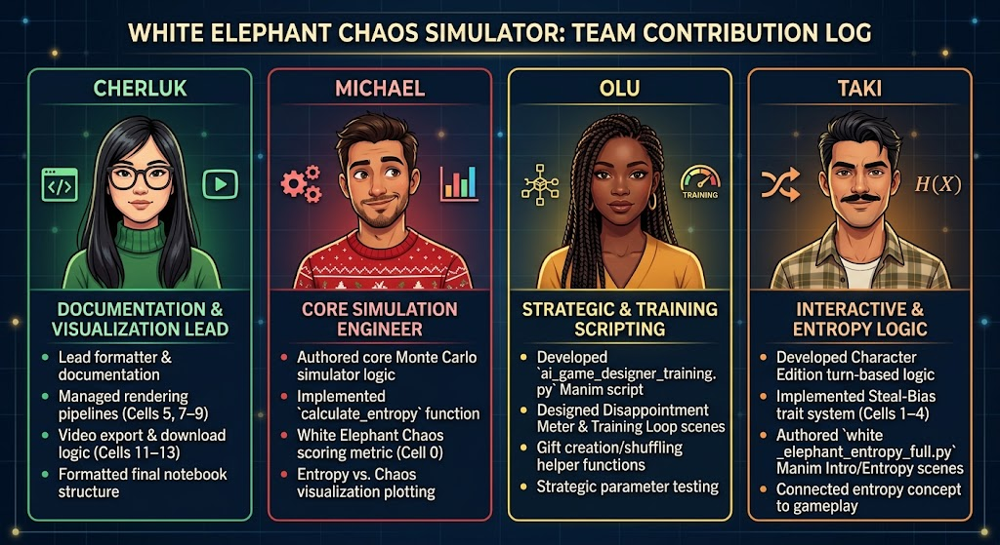

# Team Contribution Log & Reflections

**Cherluk — Documentation & Visualization Lead**
* **Code Specifics:** Managed rendering pipelines (Cells 5, 7–9), video export/download logic (Cells 11–13), formatted the final notebook structure.
* **Why this role:** Cherluk gravitates toward analytics and finding the key signal in a large amount of detail, but isn't yet as programmatically seasoned as some teammates — so documentation and formatting played to that strength while the group's more experienced coders owned the core logic.
* **Translating for an 11-year-old:** Adapted the language based on how she talks with her own younger family members — deliberately avoiding jargon so it wouldn't overwhelm or worry them. Anchoring everything to the Christmas gift-exchange game made the material feel natural rather than academic. She paced the conceptual jumps in short, deliberate steps so each idea would stick before connecting it to the real-world deep learning concept.

**Michael — Core Simulation Engineer**
* **Code Specifics:** Authored the core Monte Carlo simulator loop, implemented `calculate_entropy`, built the White Elephant Chaos scoring metric (Cell 0), entropy-vs-chaos visualization plotting.
* **Why this role:** Michael finds satisfaction in working through complex error strings and debugging — often trying multiple alternative fixes on the same problem just to see it through. His interest in entropy originally comes from chemistry (chemical engineering background), and drawing parallels between entropy in chemistry and entropy in deep learning — while noting the clear differences — gave him an adaptable perspective he could apply to the simulator's design.
* **Translating for an 11-year-old:** The "chaos score" naming was partly inspired by his interest in the mythological deity Chaos, tying the math to something evocative. Because his background leans more chemistry/technical than pedagogical, he found the kid-facing narrative translation more difficult than the coding itself — so his contribution to that side of the project showed up mainly through the video/visual elements rather than the explanatory language.

**Olu — Strategic & Training Scripting**
* **Code Specifics:** Developed `ai_game_designer_training.py` (Manim), designed the Disappointment Meter and Training Loop scenes, wrote gift creation/shuffling helper functions, ran strategic parameter testing.
* **Why this role:** Olu came in with relatively little hands-on Python experience, and working through loops in the code became a practical way to build that foundation. She approaches unfamiliar concepts by working to fully pin down and understand them rather than working around them, and her "get it done no matter what" mindset naturally suited the strategist role. She led the parameter testing between steal aggressiveness and chaos.
* **Translating for an 11-year-old:** The "Disappointment Meter" framing took the group a couple of rounds to land on — Olu brought an initial concept, then a revised version, then the final framing, workshopped over a day with the group. Explaining the training loop itself came relatively naturally to her: since she was approaching the underlying concept from a novice standpoint herself, walking someone else through it at a similarly early stage of understanding wasn't a big leap.

**Taki — Interactive & Entropy Logic**
* **Code Specifics:** Developed the Character Edition turn-based logic, implemented the steal-bias trait system (Cells 1–4), authored `white_elephant_entropy_full.py` (Manim Intro/Entropy scenes), connected the entropy concept to gameplay.
* **Why this role:** Taki learns best by having a tangible, working product in hand rather than working in the abstract. His strength is being present and responsive when the team needs him, and building something that can be reshaped quickly and easily — the character trait system reflects that, designed to be adjusted at a moment's notice.
* **Translating for an 11-year-old:** Taki initially had no clear approach for connecting entropy to gameplay. It was only after Olu's framing work — her initial concept, revision, and final version of the Disappointment Meter — that the gameplay and its explanation clicked into place for him. From there he was able to build out the character-driven interactive tool. That piece was left out of the notebook early on and came together later in the process, and Taki was the one who ultimately shaped it into the kid-facing version.

  **Known issue:** The Character Edition cells (1–4) reference an image file, `WhiteElephantRoster.jpeg`, that wasn't uploaded to the Colab session — Cell 1 throws a `FileNotFoundError` and cells 2–4 never finished running in the submitted notebook. Worth flagging here as a specific to-do, since this is Taki's section and directly affects whether it counts as "working."

---

  ## Group Reflection

The team's biggest challenge was the video creation tool used for the introduction before the gameplay sections. How to get Manim set up and rendering correctly took real trial and error. That struggle turned into one of the group's main takeaways: for a machine to make meaningful, insightful changes, it has to make a huge number of errors first! A fitting parallel to the loss/training-loop concept the project was built around. The group also learned the value of asking each other questions even when an answer might seem obvious; doing that surfaced where each person's strengths actually are, which will help how the team splits work on future projects.